# Load the dataset

The dataset contains residential property transaction records from December 2025 through May 2026, including property characteristics, pricing, location, lot information, and other key real estate attributes.


In [153]:
import pandas as pd
import glob
import os

path = r"dataset"
files = glob.glob(os.path.join(path, "*.csv"))
dataset_total_last6 = pd.concat([pd.read_csv(f) for f in files],ignore_index=True)

C:\Users\23035\AppData\Local\Temp\ipykernel_58688\1862424291.py:7: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_total_last6 = pd.concat([pd.read_csv(f) for f in files],ignore_index=True)


# Dataset Overview

The filtered dataset contains 82,643 residential property records with 79 features. Among these variables, there are 27 floating-point features, 3 integer features, and 49 categorical features. While the dataset is largely complete for the variables required in this assignment, several optional attributes contain substantial missing values, and a few columns are entirely empty (e.g., TaxAnnualAmount and FireplacesTotal). Therefore, these variables are excluded from the exploratory analysis. Following the project requirements, the subsequent EDA focuses on the distributions of ClosePrice, LivingArea, BedroomsTotal, BathroomsTotalInteger, and LotSizeSquareFeet, using only Residential Single Family Residence properties.

In [112]:
dataset_total_last6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124404 entries, 0 to 124403
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 118347 non-null  object 
 1   ListAgentAOR                  124358 non-null  object 
 2   Flooring                      72408 non-null   object 
 3   ViewYN                        112237 non-null  object 
 4   WaterfrontYN                  83 non-null      object 
 5   BasementYN                    1979 non-null    object 
 6   PoolPrivateYN                 110682 non-null  object 
 7   OriginalListPrice             124042 non-null  float64
 8   ListingKey                    124404 non-null  int64  
 9   ListAgentEmail                124134 non-null  object 
 10  CloseDate                     124404 non-null  object 
 11  ClosePrice                    124403 non-null  float64
 12  ListAgentFirstName            123903 non-nul

In [36]:
dataset_total_last6.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,1.240420e+05,1.244040e+05,1.244030e+05,124378.000000,124378.000000,115644.000000,1.242190e+05,124404.000000,0.0,0.0,...,0.0,610.000000,0.0,101630.000000,1.141430e+05,67412.000000,108122.000000,87044.000000,1.140490e+05,0.0
mean,9.196234e+05,1.146314e+09,8.976399e+05,34.506808,-118.421675,1817.942472,8.408392e+05,48.946433,NaN,NaN,...,NaN,66.021311,NaN,1.364459,4.665074e+04,1.912226,1.761011,191.041289,5.204247e+05,NaN
std,5.736495e+06,1.586868e+07,6.508684e+06,1.654612,3.296578,1238.080953,1.301304e+06,72.522144,NaN,NaN,...,NaN,369.696686,NaN,0.481281,1.909697e+06,1.440804,4.000048,424.347412,2.448794e+07,NaN
min,0.000000e+00,4.217759e+08,0.000000e+00,-44.390329,-156.450301,0.000000,1.250000e+00,-39.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,3.499900e+04,1.144917e+09,2.700000e+04,33.731644,-118.531638,1178.000000,3.000000e+04,9.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,4.932000e+03,1.000000,1.000000,0.000000,5.227000e+03,NaN
50%,6.299000e+05,1.150599e+09,6.170000e+05,34.036124,-118.044969,1582.000000,6.200000e+05,25.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.073000e+03,2.000000,2.000000,0.000000,7.405000e+03,NaN
75%,1.088000e+06,1.153606e+09,1.060000e+06,34.283515,-117.307883,2168.000000,1.050000e+06,62.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,1.179400e+04,3.000000,2.000000,304.000000,1.374900e+04,NaN
max,7.500000e+08,1.171673e+09,7.960000e+08,47.223455,171.226180,105369.000000,6.500000e+07,2443.000000,NaN,NaN,...,NaN,7009.000000,NaN,2.000000,4.187423e+08,44.000000,600.000000,20712.000000,5.193920e+09,NaN


## Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize

All analysis is restricted to Residential properties with PropertySubType = SingleFamilyResidence.

In [37]:
dataset_total_last6_r=dataset_total_last6[dataset_total_last6["PropertyType"].isin(["Residential", "SingleFamilyResidence"] )]

In [107]:
dataset_total_last6_r.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,Record_date
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN,2025-12
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN,2025-12
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN,2025-12
7,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN,2025-12
9,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,NaN,2025-12


## Dataset Information

The dataset contains **79 features** and **82,643 records** after filtering to Residential Single Family Residence properties.

## Missing Value Summary

### Features with No Missing Values

The following features contain complete records (82,643 non-null values):

* ListingKey
* CloseDate
* ClosePrice
* PropertyType
* ListPrice
* DaysOnMarket
* ListOfficeName
* ListingKeyNumeric
* CountyOrParish
* MlsStatus
* ParkingTotal
* ListingId
* ContractStatusChangeDate
* ListingContractDate
* StateOrProvince
* Record_date

### Features with 100% Missing Values

The following features contain no non-null values and were excluded from the analysis:

* FireplacesTotal
* AboveGradeFinishedArea
* TaxAnnualAmount
* TaxYear
* ElementarySchoolDistrict
* BusinessType
* CoveredSpaces
* MiddleOrJuniorSchoolDistrict

### Features with High Missing Rates

Several features contain substantial missing values and were not used in the exploratory analysis:

* WaterfrontYN
* BasementYN
* BuilderName
* BuildingAreaTotal
* BelowGradeFinishedArea
* LotSizeDimensions
* ElementarySchool
* MiddleOrJuniorSchool
* HighSchool
* CoBuyerAgentFirstName
* CoListOfficeName
* CoListAgentFirstName
* CoListAgentLastName
* SubdivisionName
* AssociationFeeFrequency

### Features Used for EDA

The exploratory data analysis focuses on variables with high data completeness:

* ClosePrice
* LivingArea
* BedroomsTotal
* BathroomsTotalInteger
* LotSizeSquareFeet
* LotSizeArea
* LotSizeDimensions
* LotSizeSquareFeet




In [38]:
dataset_total_last6_r.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 82643 entries, 0 to 124400
Data columns (total 79 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuyerAgentAOR                 77616 non-null  object 
 1   ListAgentAOR                  82623 non-null  object 
 2   Flooring                      52523 non-null  object 
 3   ViewYN                        75862 non-null  object 
 4   WaterfrontYN                  67 non-null     object 
 5   BasementYN                    1577 non-null   object 
 6   PoolPrivateYN                 76840 non-null  object 
 7   OriginalListPrice             82477 non-null  float64
 8   ListingKey                    82643 non-null  int64  
 9   ListAgentEmail                82465 non-null  object 
 10  CloseDate                     82643 non-null  object 
 11  ClosePrice                    82643 non-null  float64
 12  ListAgentFirstName            82184 non-null  object 
 13  

Statistics of numerical type characteristics

In [39]:
dataset_total_last6_r.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,8.247700e+04,8.264300e+04,8.264300e+04,82631.000000,82631.000000,82602.000000,8.264300e+04,82643.000000,0.0,0.0,...,0.0,553.000000,0.0,71494.000000,7.672300e+04,48889.000000,78996.000000,64789.000000,7.669500e+04,0.0
mean,1.240477e+06,1.146447e+09,1.233005e+06,34.636149,-118.539485,1883.891046,1.148081e+06,43.401619,NaN,NaN,...,NaN,48.271248,NaN,1.364730,4.276512e+04,2.040643,1.871987,245.656095,4.055767e+05,NaN
std,6.191915e+06,1.273472e+07,7.674527e+06,1.775293,3.036172,988.919604,1.374044e+06,58.807183,NaN,NaN,...,NaN,208.738383,NaN,0.481358,2.219671e+06,1.478354,3.974571,464.905398,1.847170e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,-22.863239,-124.175789,0.000000,5.000000e+03,-39.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,5.800000e+05,1.144663e+09,5.696560e+05,33.722297,-118.874527,1258.000000,5.750000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.000000e+03,1.000000,2.000000,0.000000,5.253000e+03,NaN
50%,8.250000e+05,1.150601e+09,8.150000e+05,34.040438,-117.999156,1661.000000,8.050000e+05,21.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.002000e+03,2.000000,2.000000,98.000000,7.318000e+03,NaN
75%,1.299000e+06,1.153564e+09,1.298000e+06,34.548073,-117.248690,2251.000000,1.295000e+06,56.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,1.104000e+04,3.000000,2.000000,392.000000,1.245400e+04,NaN
max,7.250000e+08,1.171673e+09,7.960000e+08,43.784440,118.140030,28502.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,4.187423e+08,44.000000,600.000000,20712.000000,1.897866e+09,NaN


# Dirstibution

Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, bathrooms, LotSize.

## 1. Close price 

**Definition**: The amount of money paid by the purchaser to the seller for the property under the agreement.

**Distribution Analysis**: 

**ClosePrice** contains no missing values.The histogram of **ClosePrice** (excluding the top 1% of extreme values) shows that the sale prices are positively skewed. Most properties were sold between approximately $400,000$ and $1,400,000$, with the highest concentration around $600,000$–$900,000$. As the sale price increases, the number of properties gradually decreases, resulting in a long right tail, which indicates that while most transactions occur within a moderate price range, a relatively small number of high-value properties contribute to the upper end of the price distribution. Among all sale prices, $650,000$ and $750,000$, are the most common transaction prices, with $596$, $595$ properties sold at each price point, respectively.

The box plot indicates that the distribution of **ClosePrice** is highly right-skewed. Most properties are sold below **$1.3$ million** (75th  percentile), while a small number of properties have exceptionally high sale prices, resulting in numerous high-value outliers. The maximum recorded sale price is approximately **$796$ million**, which is substantially higher than the median sale price of **$815,000$**. These outliers are likely associated with luxury or premium properties and are retained during the exploratory data analysis stage.

In [113]:
dataset_total_last6_r["ClosePrice"].value_counts()

650000.0      596
750000.0      595
850000.0      567
800000.0      561
1200000.0     550
             ... 
1587777.0       1
1881000.0       1
696250.0        1
1324307.0       1
21500000.0      1
Name: ClosePrice, Length: 8592, dtype: int64

In [115]:
dataset_total_last6_r["ClosePrice"].describe()

count    8.264300e+04
mean     1.233005e+06
std      7.674527e+06
min      1.750000e+00
25%      5.696560e+05
50%      8.150000e+05
75%      1.298000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64

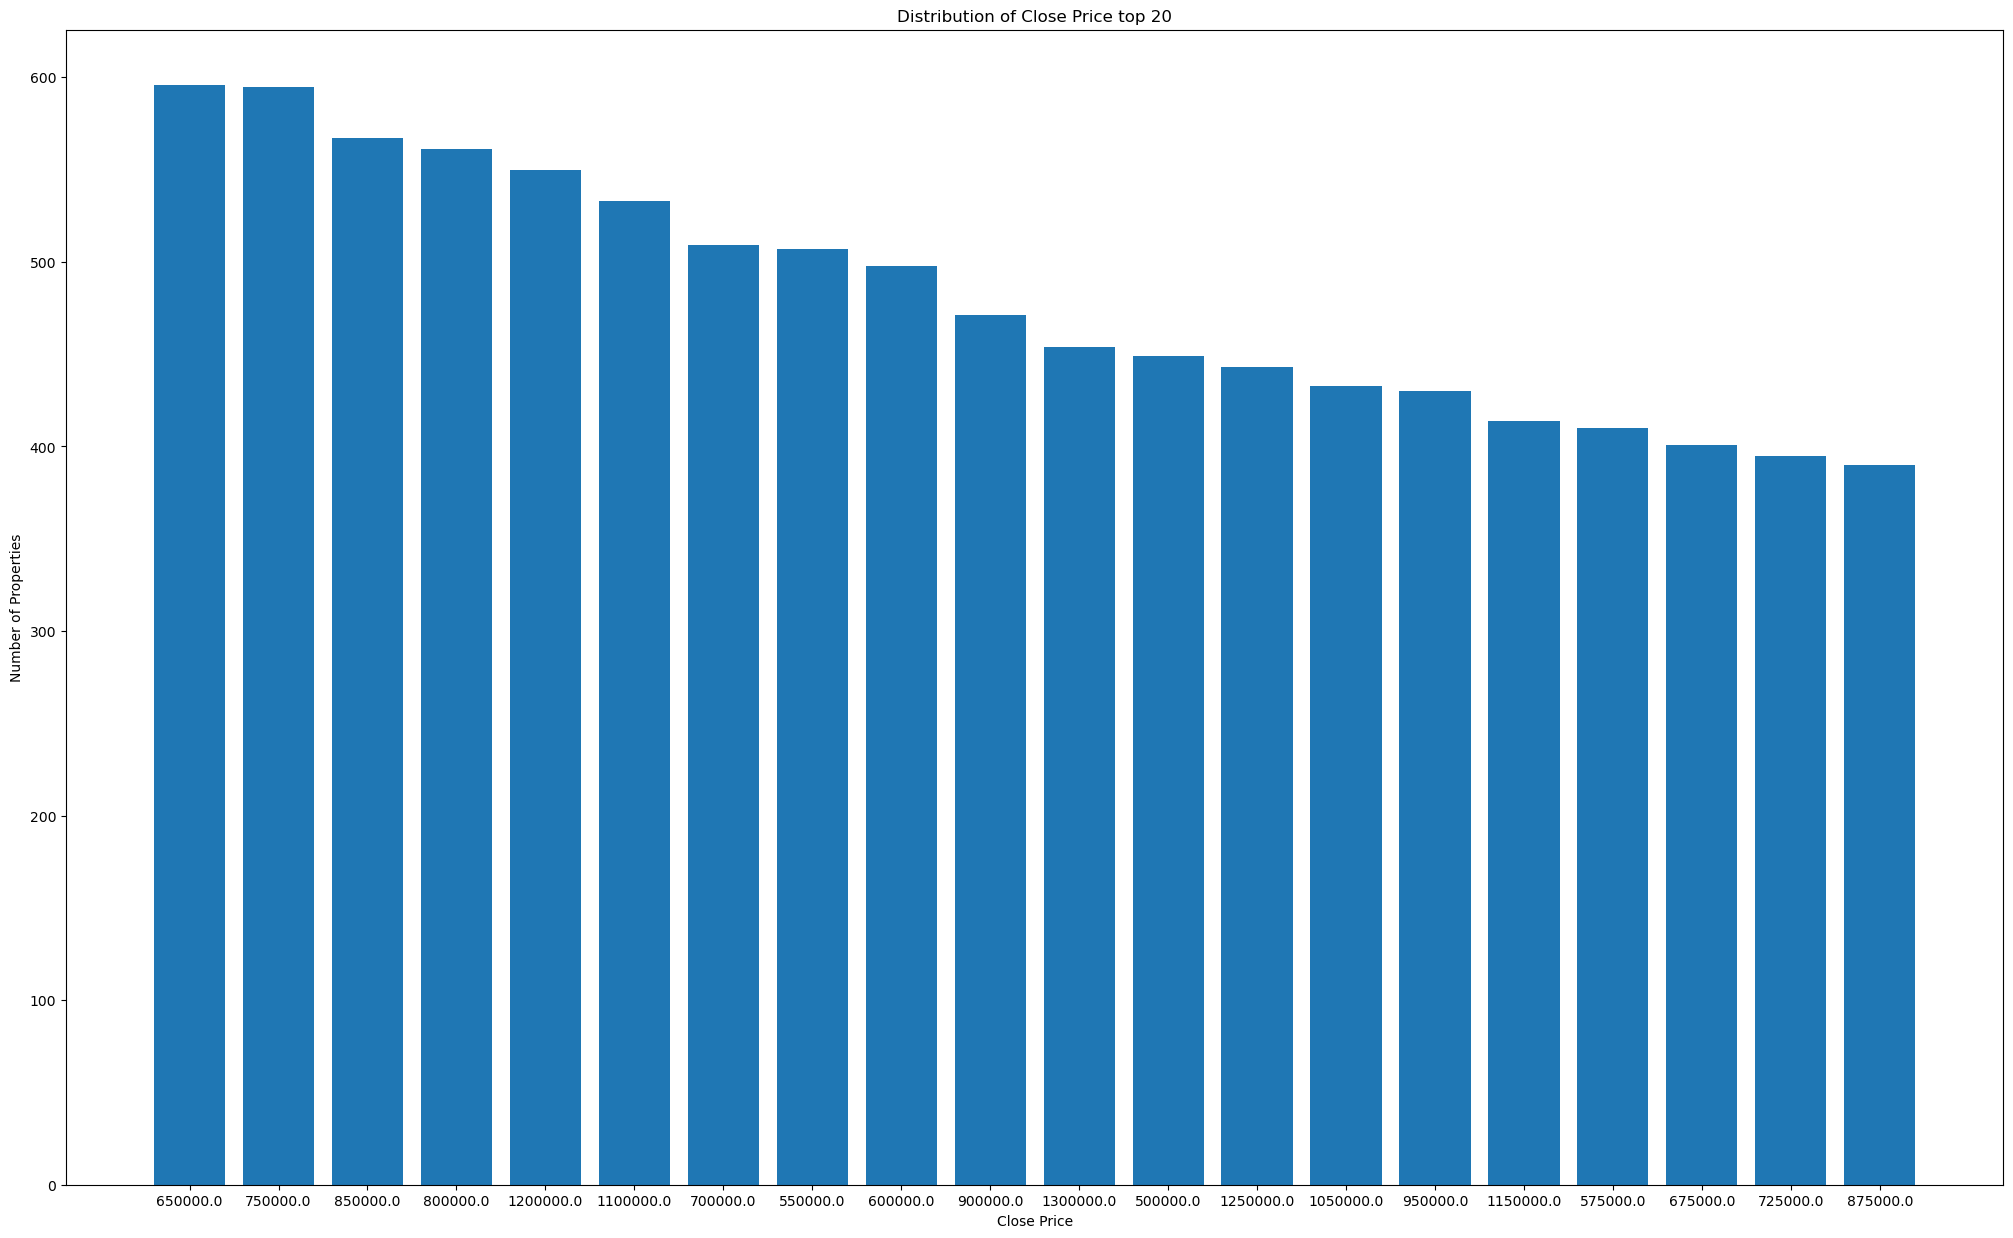

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["ClosePrice"].value_counts().head(20).index.astype(str),dataset_total_last6_r["ClosePrice"].value_counts().head(20).values)
plt.xlabel("Close Price")
plt.ylabel("Number of Properties")
plt.title("Distribution of Close Price top 20")
plt.show()

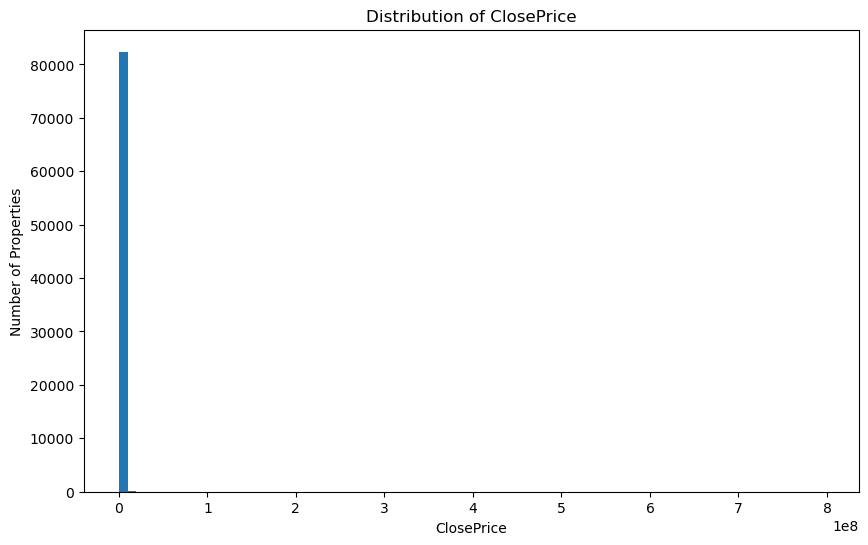

In [116]:
upper = dataset_total_last6_r["ClosePrice"]
data = dataset_total_last6_r[ dataset_total_last6_r["ClosePrice"] <= upper]["ClosePrice"]
plt.figure(figsize=(10,6))
plt.hist(data, bins=80)
plt.xlabel("ClosePrice")
plt.ylabel("Number of Properties")
plt.title("Distribution of ClosePrice")
plt.show()

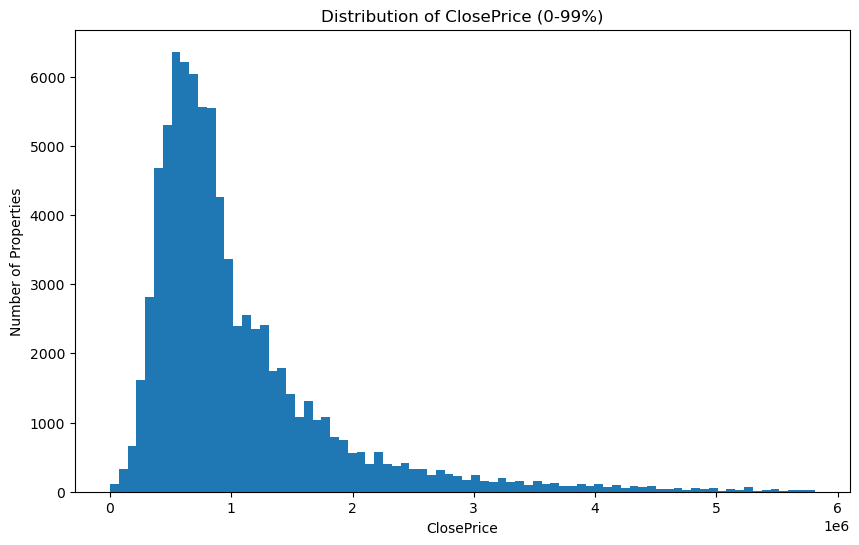

In [104]:
upper = dataset_total_last6_r["ClosePrice"].quantile(0.99)
data = dataset_total_last6_r[ dataset_total_last6_r["ClosePrice"] <= upper]["ClosePrice"]
plt.figure(figsize=(10,6))
plt.hist(data, bins=80)
plt.xlabel("ClosePrice")
plt.ylabel("Number of Properties")
plt.title("Distribution of ClosePrice (0-99%)")
plt.show()

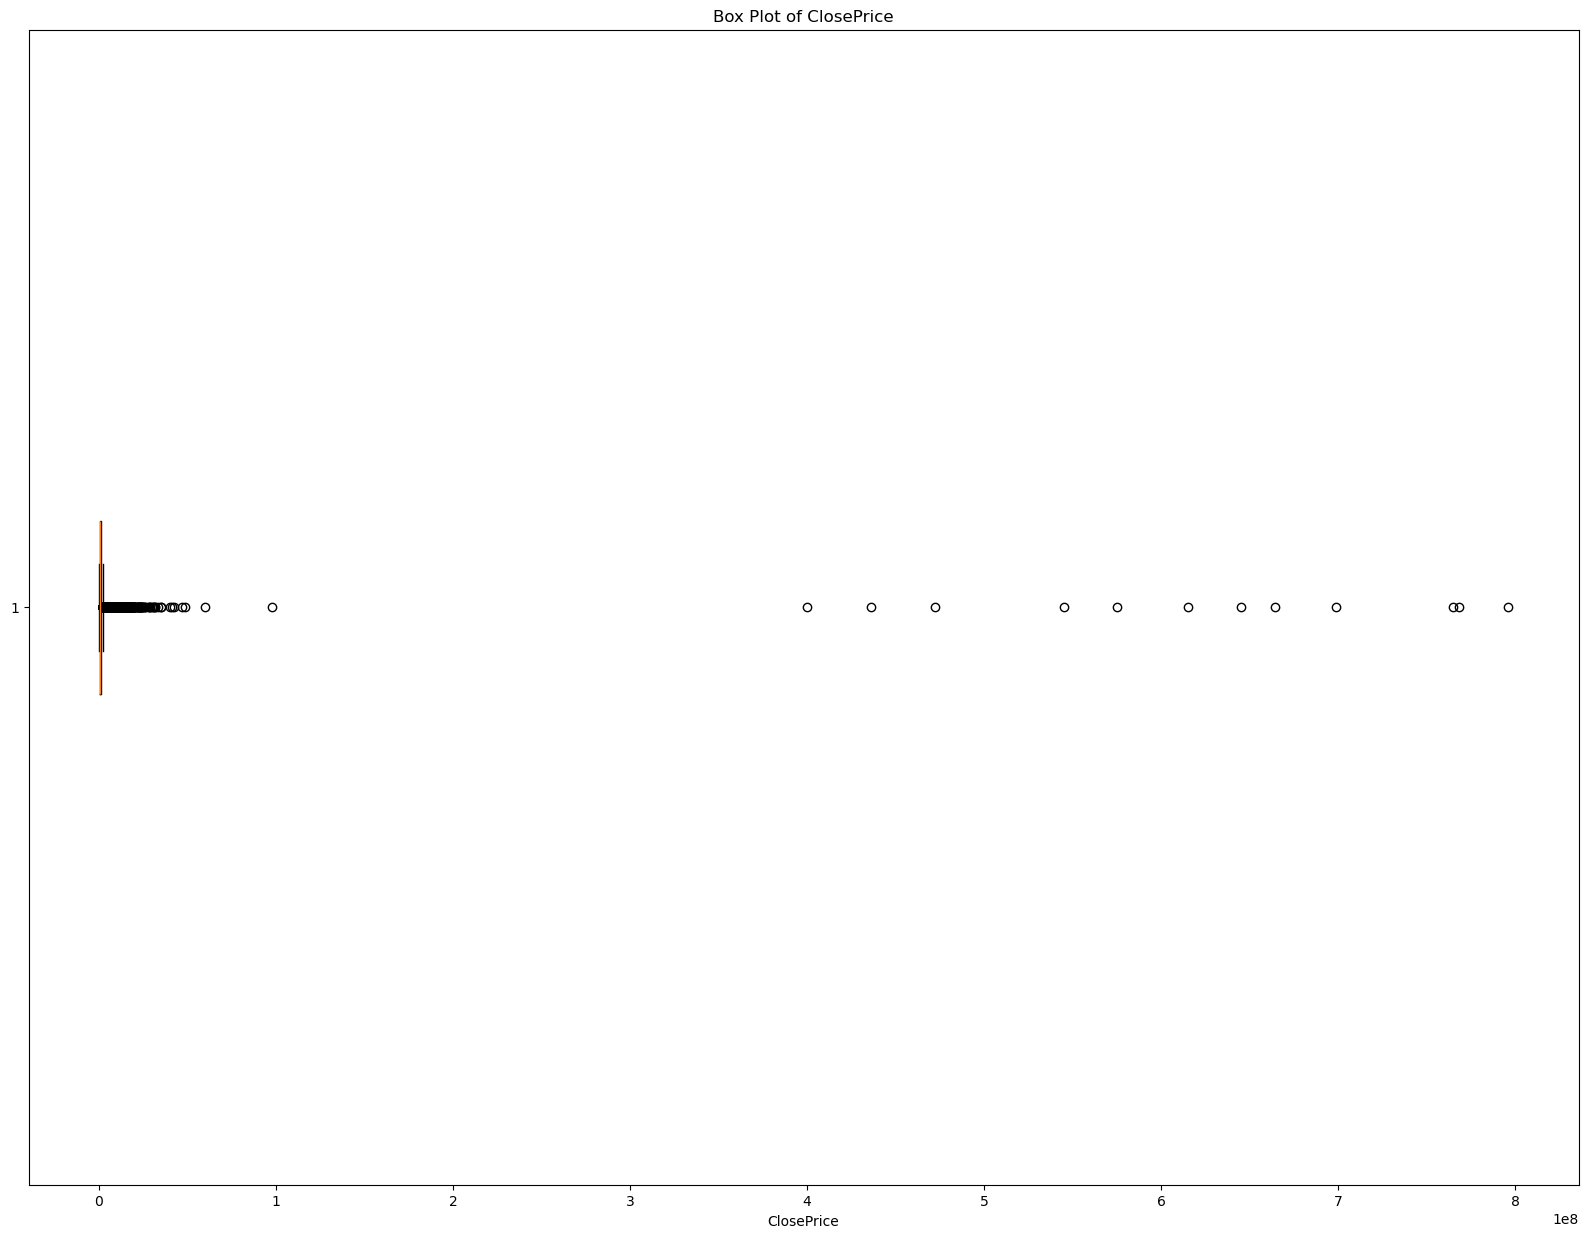

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["ClosePrice"].dropna(), vert=False)

plt.title("Box Plot of ClosePrice")
plt.xlabel("ClosePrice")
plt.show()

## 2. LivingArea 

**Definition**: The total livable area within the structure.

**Distribution Analysis:**

**LivingArea** contains very few missing values (82,602 out of 82,643 records are available, with only 41 missing values, approximately **0.05%**). The histogram (excluding the top 1% of extreme values) shows that the distribution of **LivingArea** is positively skewed. Most properties have relatively moderate living areas, with the majority concentrated between approximately **500 and 2,600 sq ft**. The frequency gradually decreases as the living area increases, resulting in a long right tail. The most common living area is **1,200 sq ft**, which appears in **299** properties, followed by **1,440 sq ft** (252 properties), **1,300 sq ft** (194 properties), and **1,344 sq ft** (190 properties).

The box plot further confirms that **LivingArea** is positively skewed and contains numerous upper-end outliers. While most properties fall within a relatively compact range, a small number of homes have exceptionally large living areas, extending the upper tail of the distribution. These observations are likely associated with luxury or specialty properties rather than data quality issues and are therefore retained during the exploratory data analysis stage.

<span style="color:red">Additionally, 37 records contain LivingArea values of 0, which are not valid physical measurements. These entries are treated as implicitly missing values and are addressed in the preprocessing stage.</span>

In [42]:
dataset_total_last6_r["LivingArea"].value_counts()

1200.0     299
1440.0     252
1300.0     194
1344.0     190
1080.0     181
          ... 
5287.0       1
457.0        1
4348.0       1
5906.0       1
23314.0      1
Name: LivingArea, Length: 5160, dtype: int64

In [124]:
dataset_total_last6_r["LivingArea"].dropna().describe()

count    82602.000000
mean      1883.891046
std        988.919604
min          0.000000
25%       1258.000000
50%       1661.000000
75%       2251.000000
max      28502.000000
Name: LivingArea, dtype: float64

In [129]:
sum(dataset_total_last6_r["LivingArea"] == 0)

37

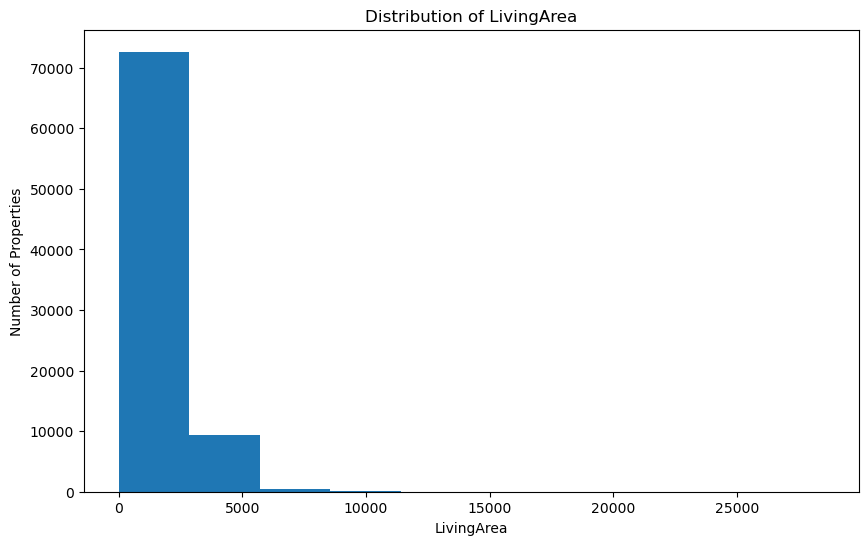

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["LivingArea"])
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LivingArea")
plt.show()

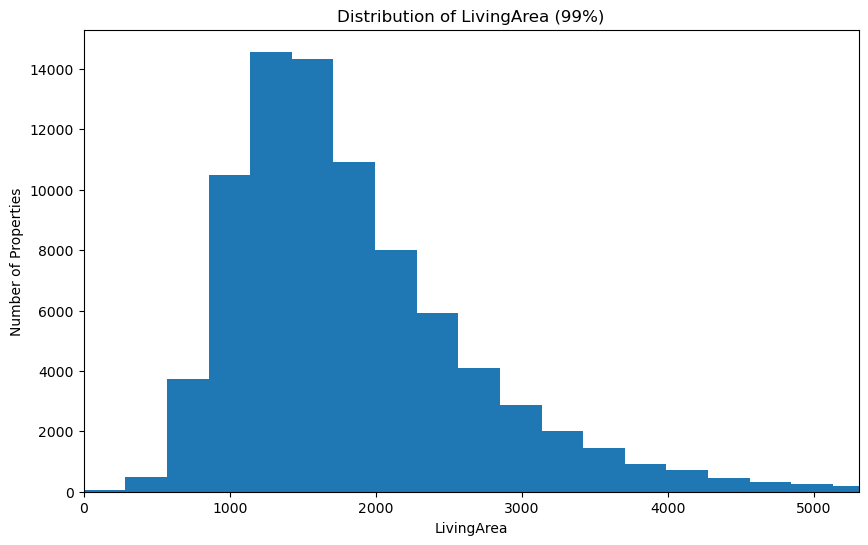

In [121]:
import matplotlib.pyplot as plt
upper = dataset_total_last6_r["LivingArea"].quantile(0.99)
plt.figure(figsize=(10,6))
plt.hist(dataset_total_last6_r["LivingArea"], bins=100)
plt.xlim(0, upper)
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LivingArea (99%)")
plt.show()

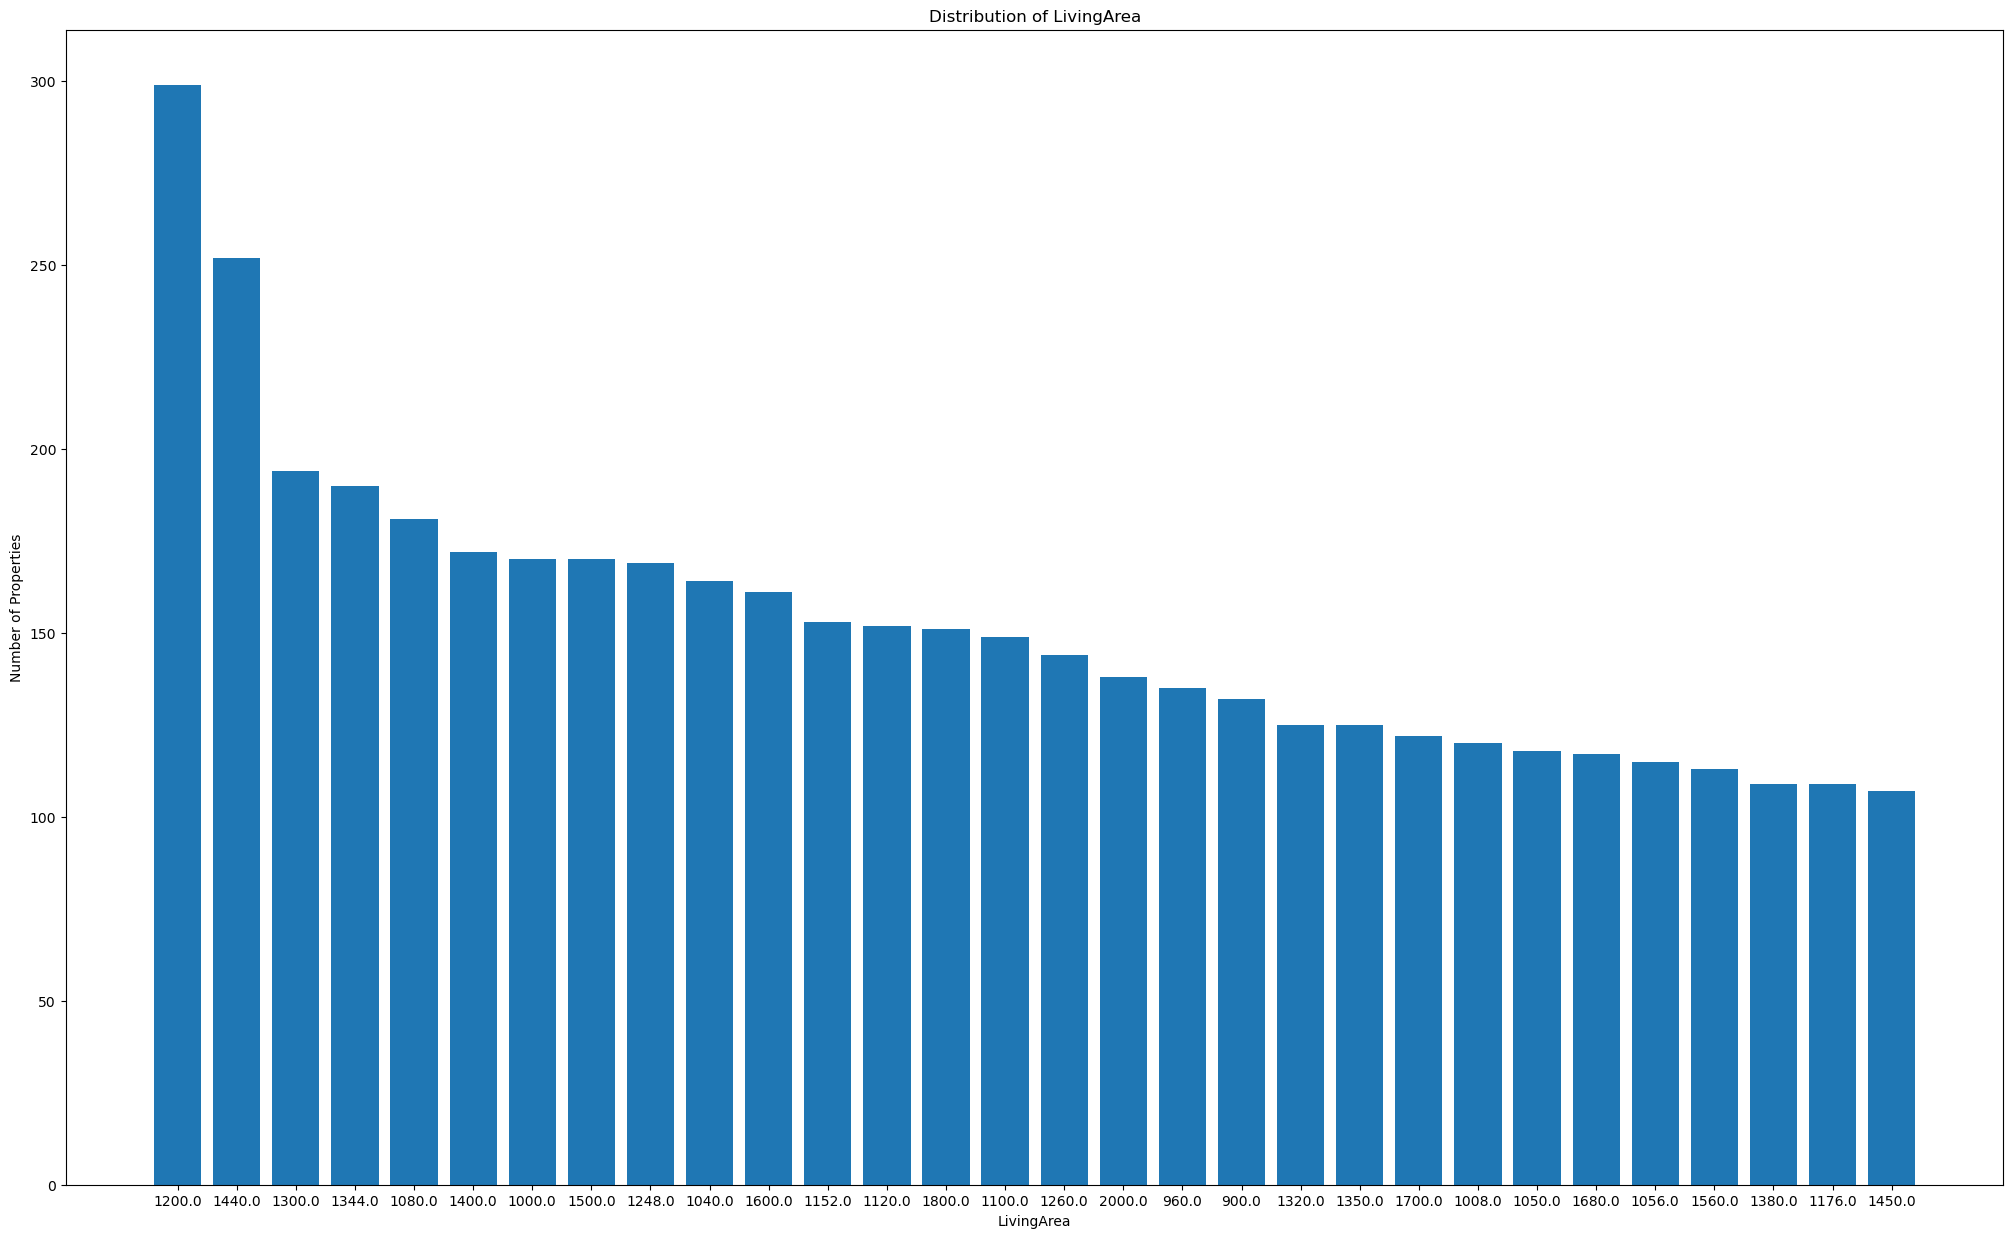

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["LivingArea"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["LivingArea"].value_counts().head(30).values)
plt.xlabel("LivingArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LivingArea")
plt.show()

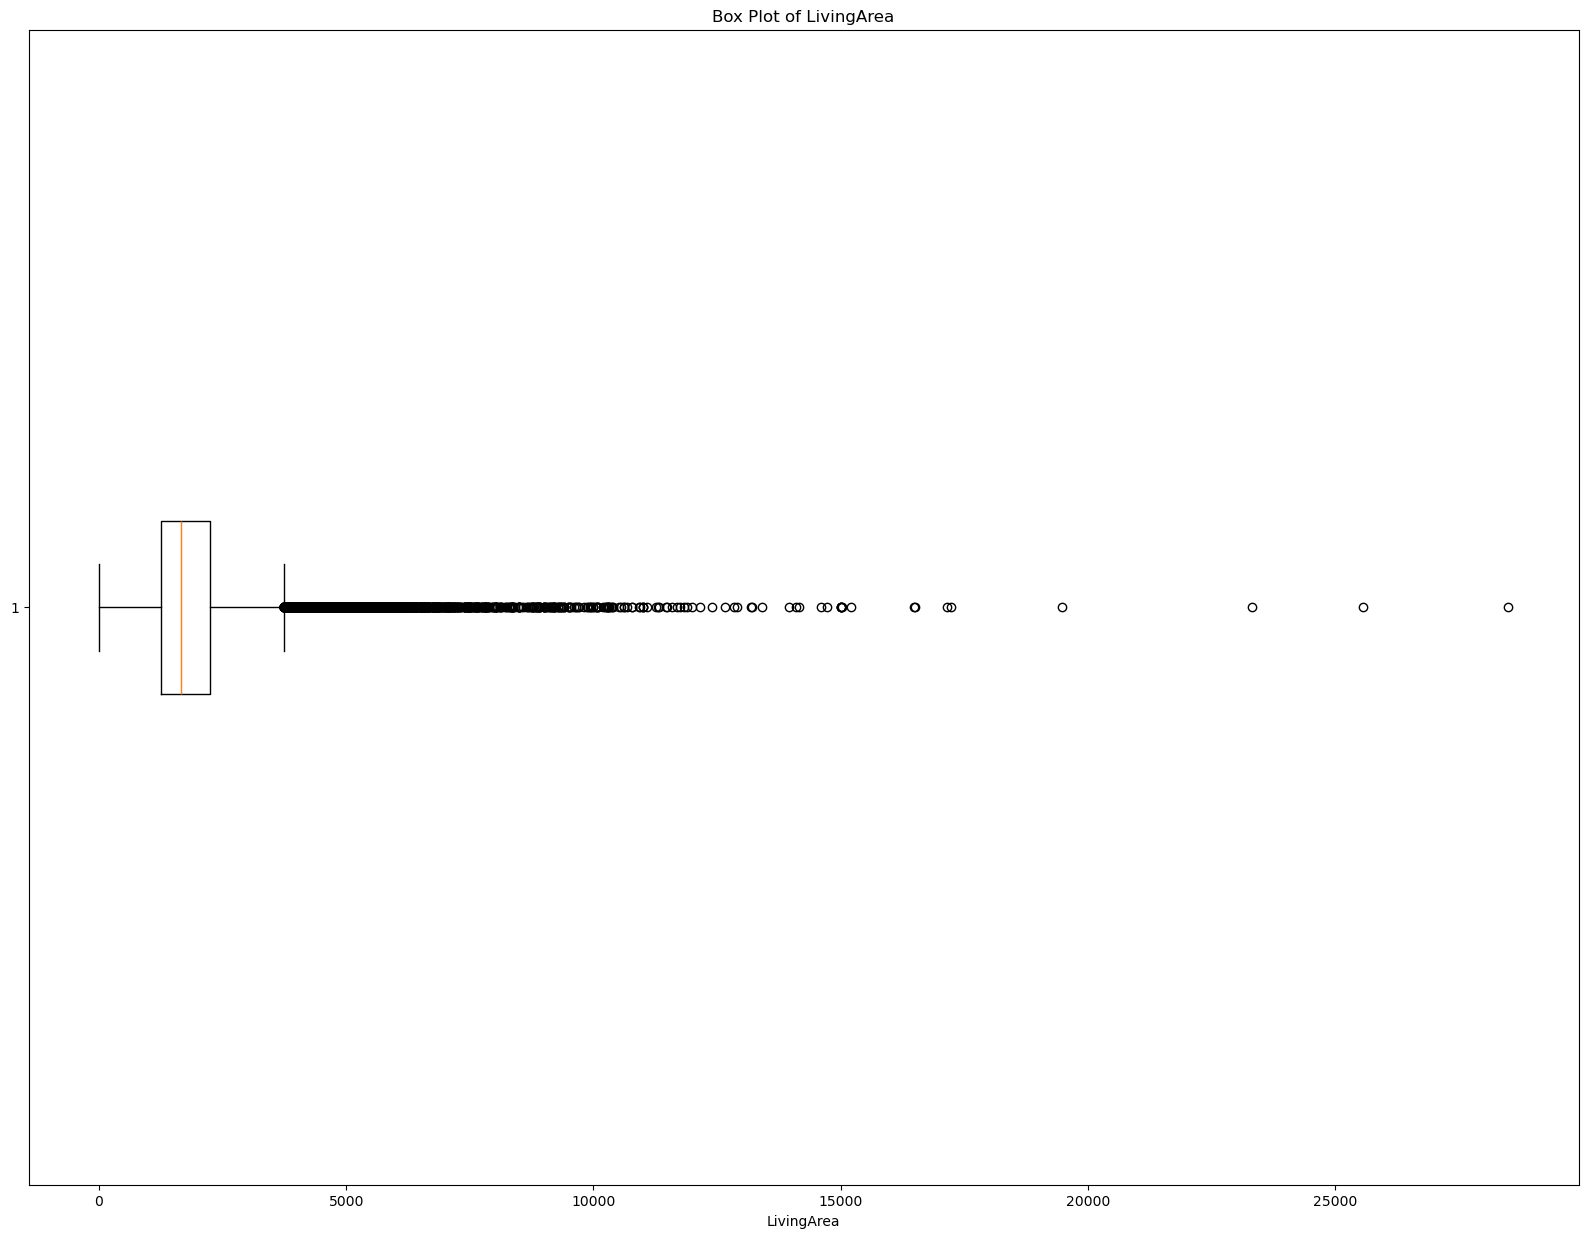

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["LivingArea"].dropna(), vert=False)

plt.title("Box Plot of LivingArea")
plt.xlabel("LivingArea")
plt.show()

# 3. Bathrooms

**Definition of BathroomsTotalInteger**: The simple sum of the number of bathrooms. For example for a property with two Full Bathrooms and one Half Bathroom, the Bathrooms Total Integer will be 3. Expressing this example as 2.5, you will need to use a non-standard field name. Decimal based bathrooms are not recommended but possible via the Dictionary's extensibility.


**Distribution Analysis:**

The dataset contains a very small number of missing values in the Bathroom variable (3 records). The distribution of bathroom counts is highly concentrated between 1 and 4, indicating a strong central tendency in residential properties. The most common values are 2 and 3 bathrooms, with frequencies of 35,542 and 27,589 respectively. In addition, 80 records have Bathroom values recorded as 0, which are likely not valid physical measurements and are therefore treated as implicitly missing values during preprocessing.

The boxplot shows that the majority of values are concentrated within the interquartile range, with only a small number of observations exceeding the upper whisker. These points can be considered high-end outliers in the distribution.

In [43]:
dataset_total_last6_r["BathroomsTotalInteger"].value_counts()

2.0     35542
3.0     27589
1.0      8832
4.0      6581
5.0      2437
6.0       951
7.0       356
8.0       148
0.0        80
9.0        53
10.0       32
11.0       14
12.0       10
13.0        7
15.0        2
14.0        2
21.0        1
18.0        1
16.0        1
22.0        1
Name: BathroomsTotalInteger, dtype: int64

In [123]:
dataset_total_last6_r["BathroomsTotalInteger"].dropna().describe()

count    82640.000000
mean         2.563783
std          1.086978
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         22.000000
Name: BathroomsTotalInteger, dtype: float64

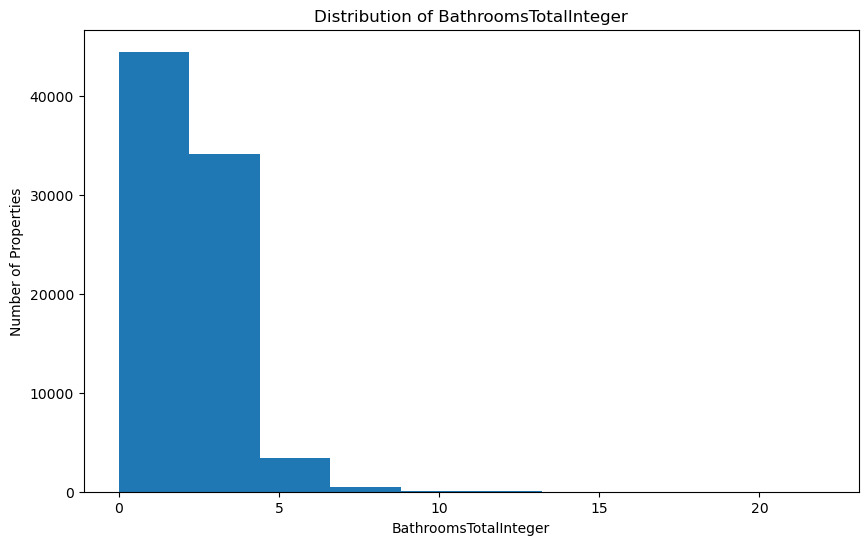

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["BathroomsTotalInteger"])
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.title("Distribution of BathroomsTotalInteger")
plt.show()

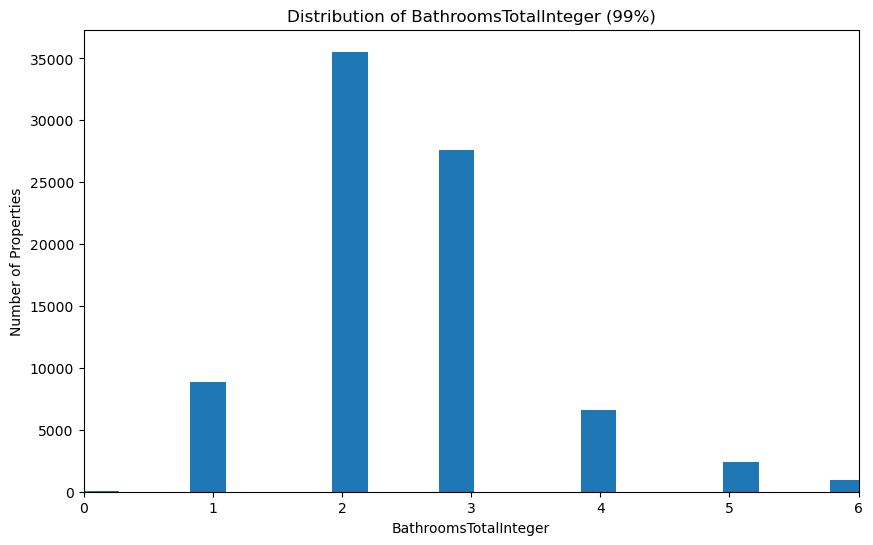

In [99]:
import matplotlib.pyplot as plt
upper = dataset_total_last6_r["BathroomsTotalInteger"].quantile(0.99)
plt.figure(figsize=(10,6))
plt.hist(dataset_total_last6_r["BathroomsTotalInteger"], bins=80)
plt.xlim(0, upper)
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.title("Distribution of BathroomsTotalInteger (99%)")
plt.show()

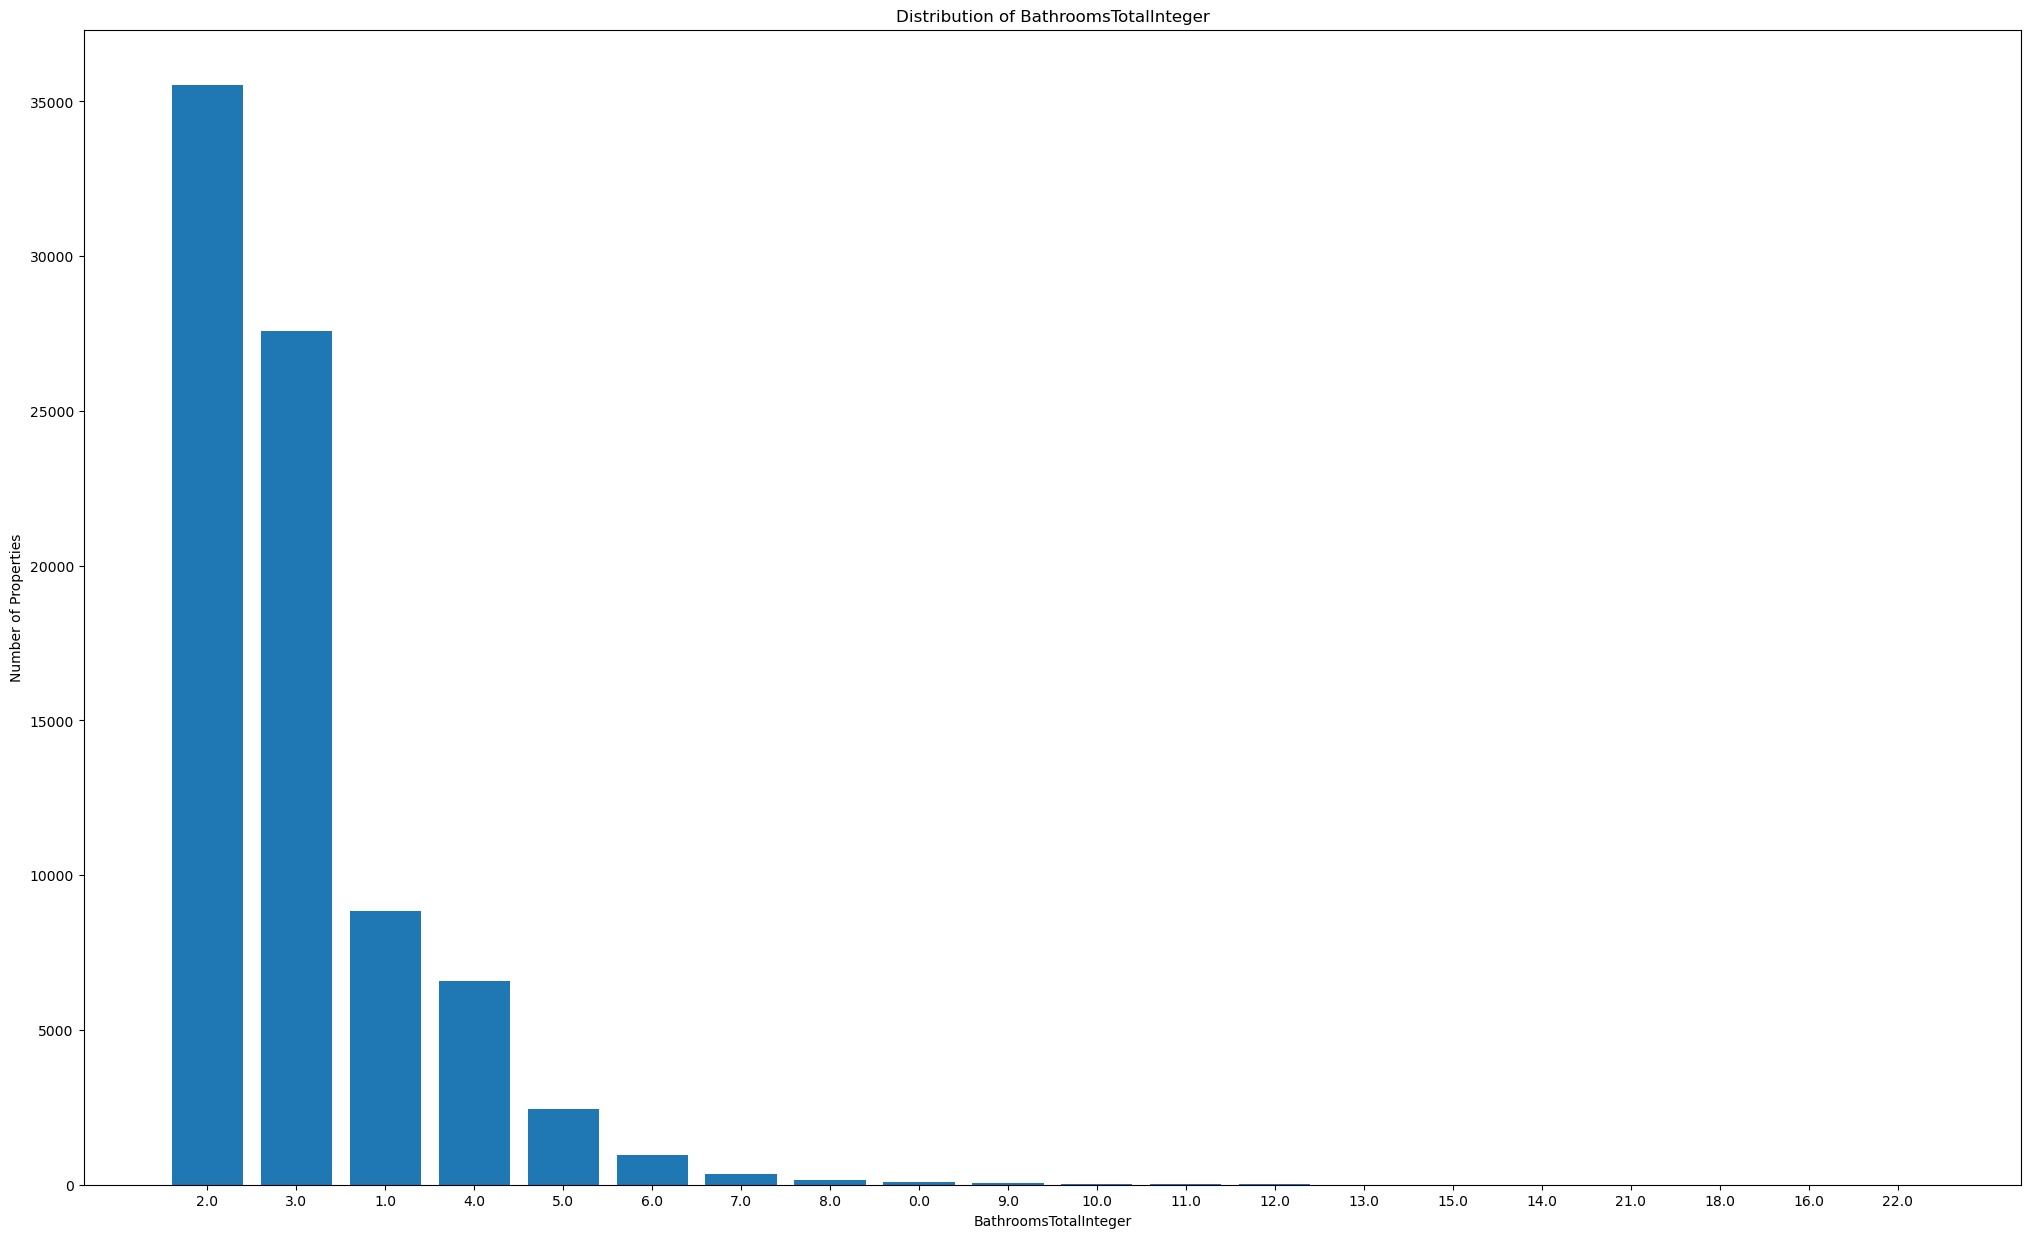

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["BathroomsTotalInteger"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["BathroomsTotalInteger"].value_counts().head(30).values)
plt.xlabel("BathroomsTotalInteger")
plt.ylabel("Number of Properties")
plt.title("Distribution of BathroomsTotalInteger")
plt.show()

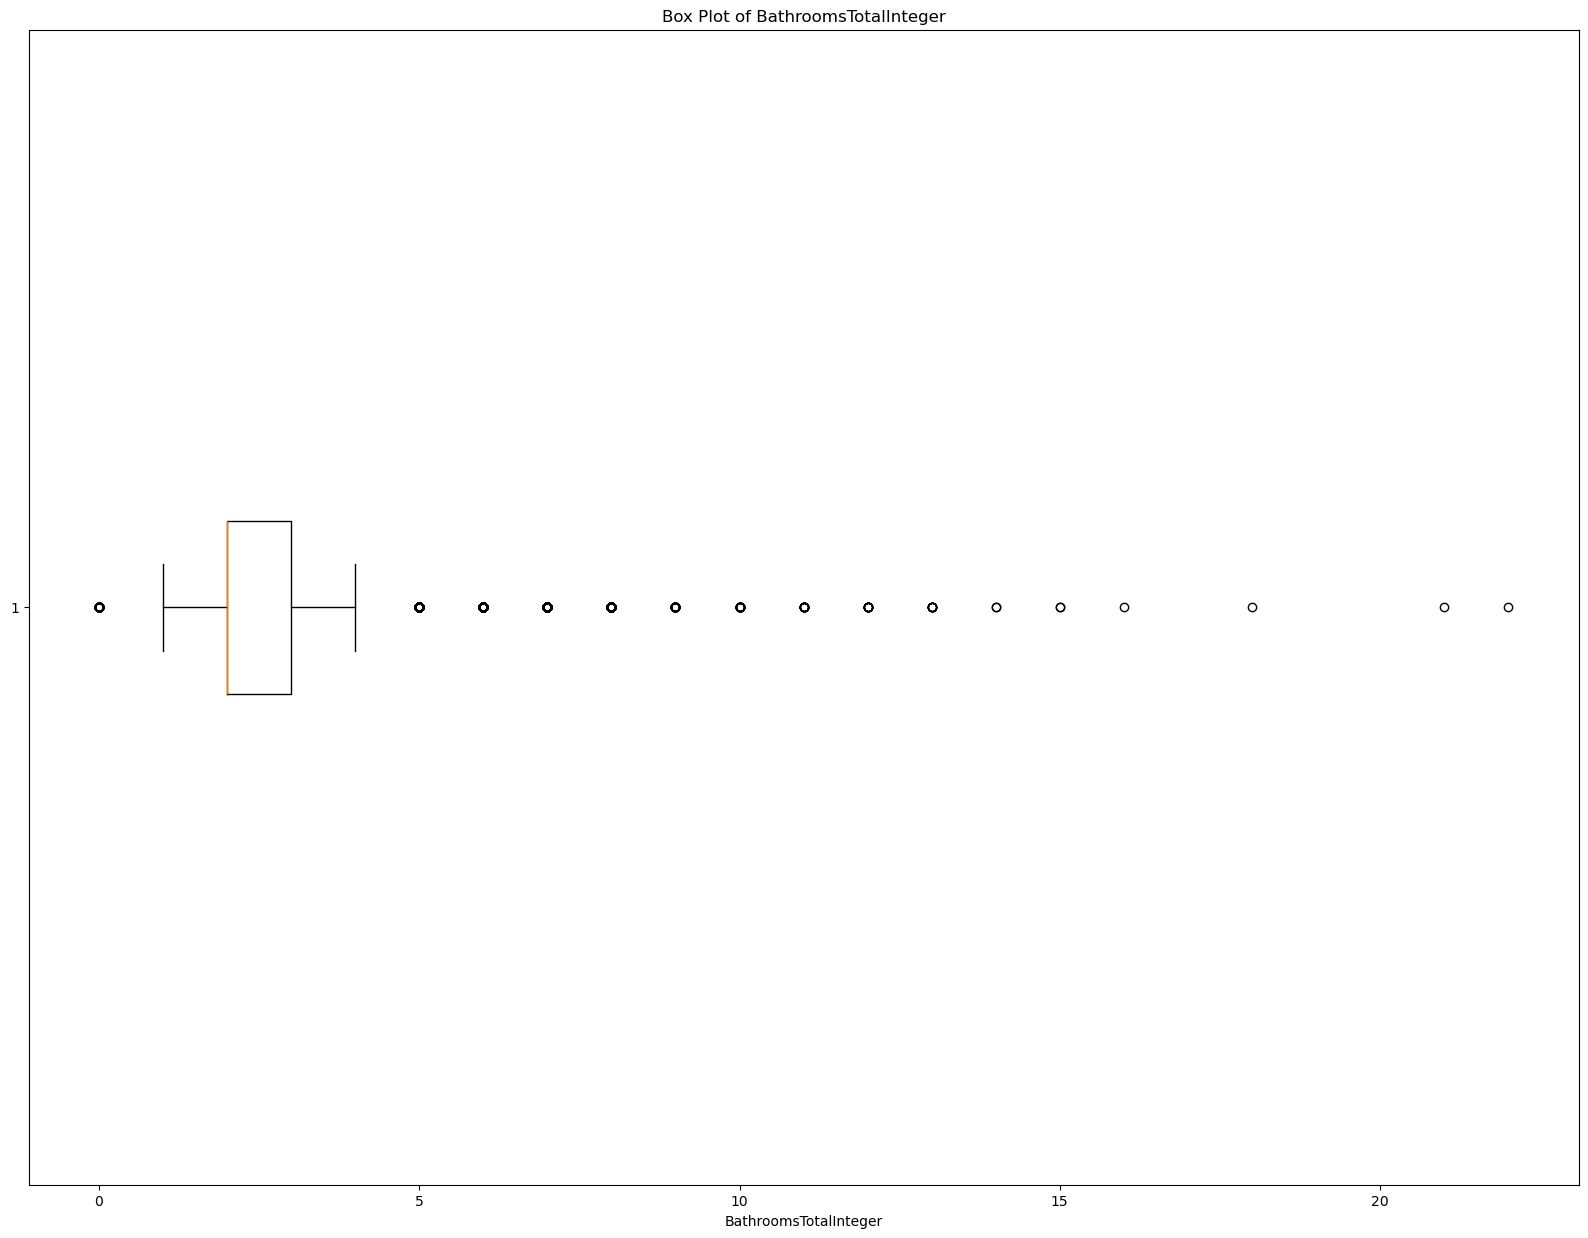

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["BathroomsTotalInteger"].dropna(), vert=False)

plt.title("Box Plot of BathroomsTotalInteger")
plt.xlabel("BathroomsTotalInteger")
plt.show()

## 4. Bedrooms

**Definition of BedroomsTotal**: The total number of bedrooms in the dwelling.

**Distribution Analysis:**

The dataset contains a very small number of missing values in the Bathroom variable (3 records). The distribution of bedrooms is concentrated between 1 and 5, with the most common values being 3, 4, and 2 bedrooms, occurring 32,414, 22,188, and 16,812 times respectively.

The boxplot shows that most values are concentrated within the interquartile range, while a small number of observations lie outside the whiskers on both the lower and upper ends, indicating the presence of outliers in the distribution.

In [44]:
dataset_total_last6_r["BedroomsTotal"].value_counts()

3.0     32414
4.0     22188
2.0     16812
5.0      6724
1.0      2629
6.0      1252
7.0       250
0.0       241
8.0        77
10.0       19
9.0        19
11.0        5
12.0        5
16.0        2
20.0        1
22.0        1
24.0        1
Name: BedroomsTotal, dtype: int64

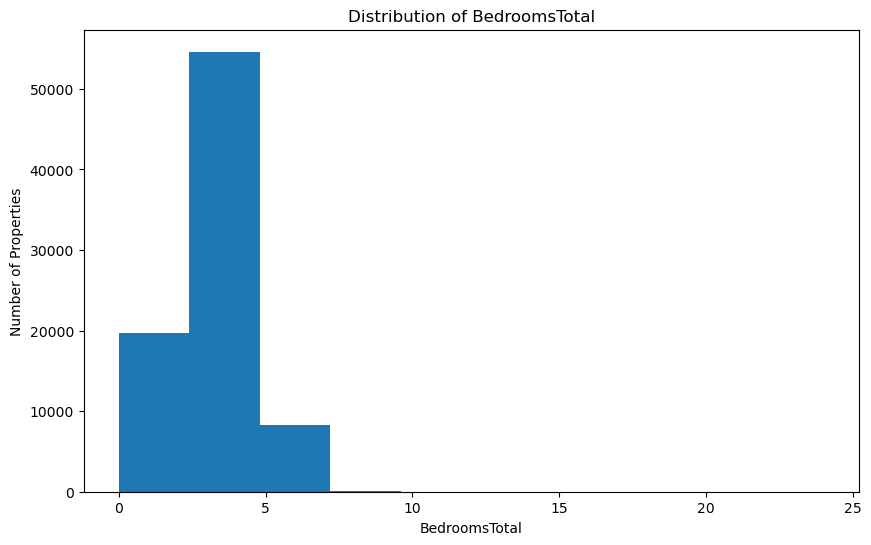

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["BedroomsTotal"])
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.title("Distribution of BedroomsTotal")
plt.show()

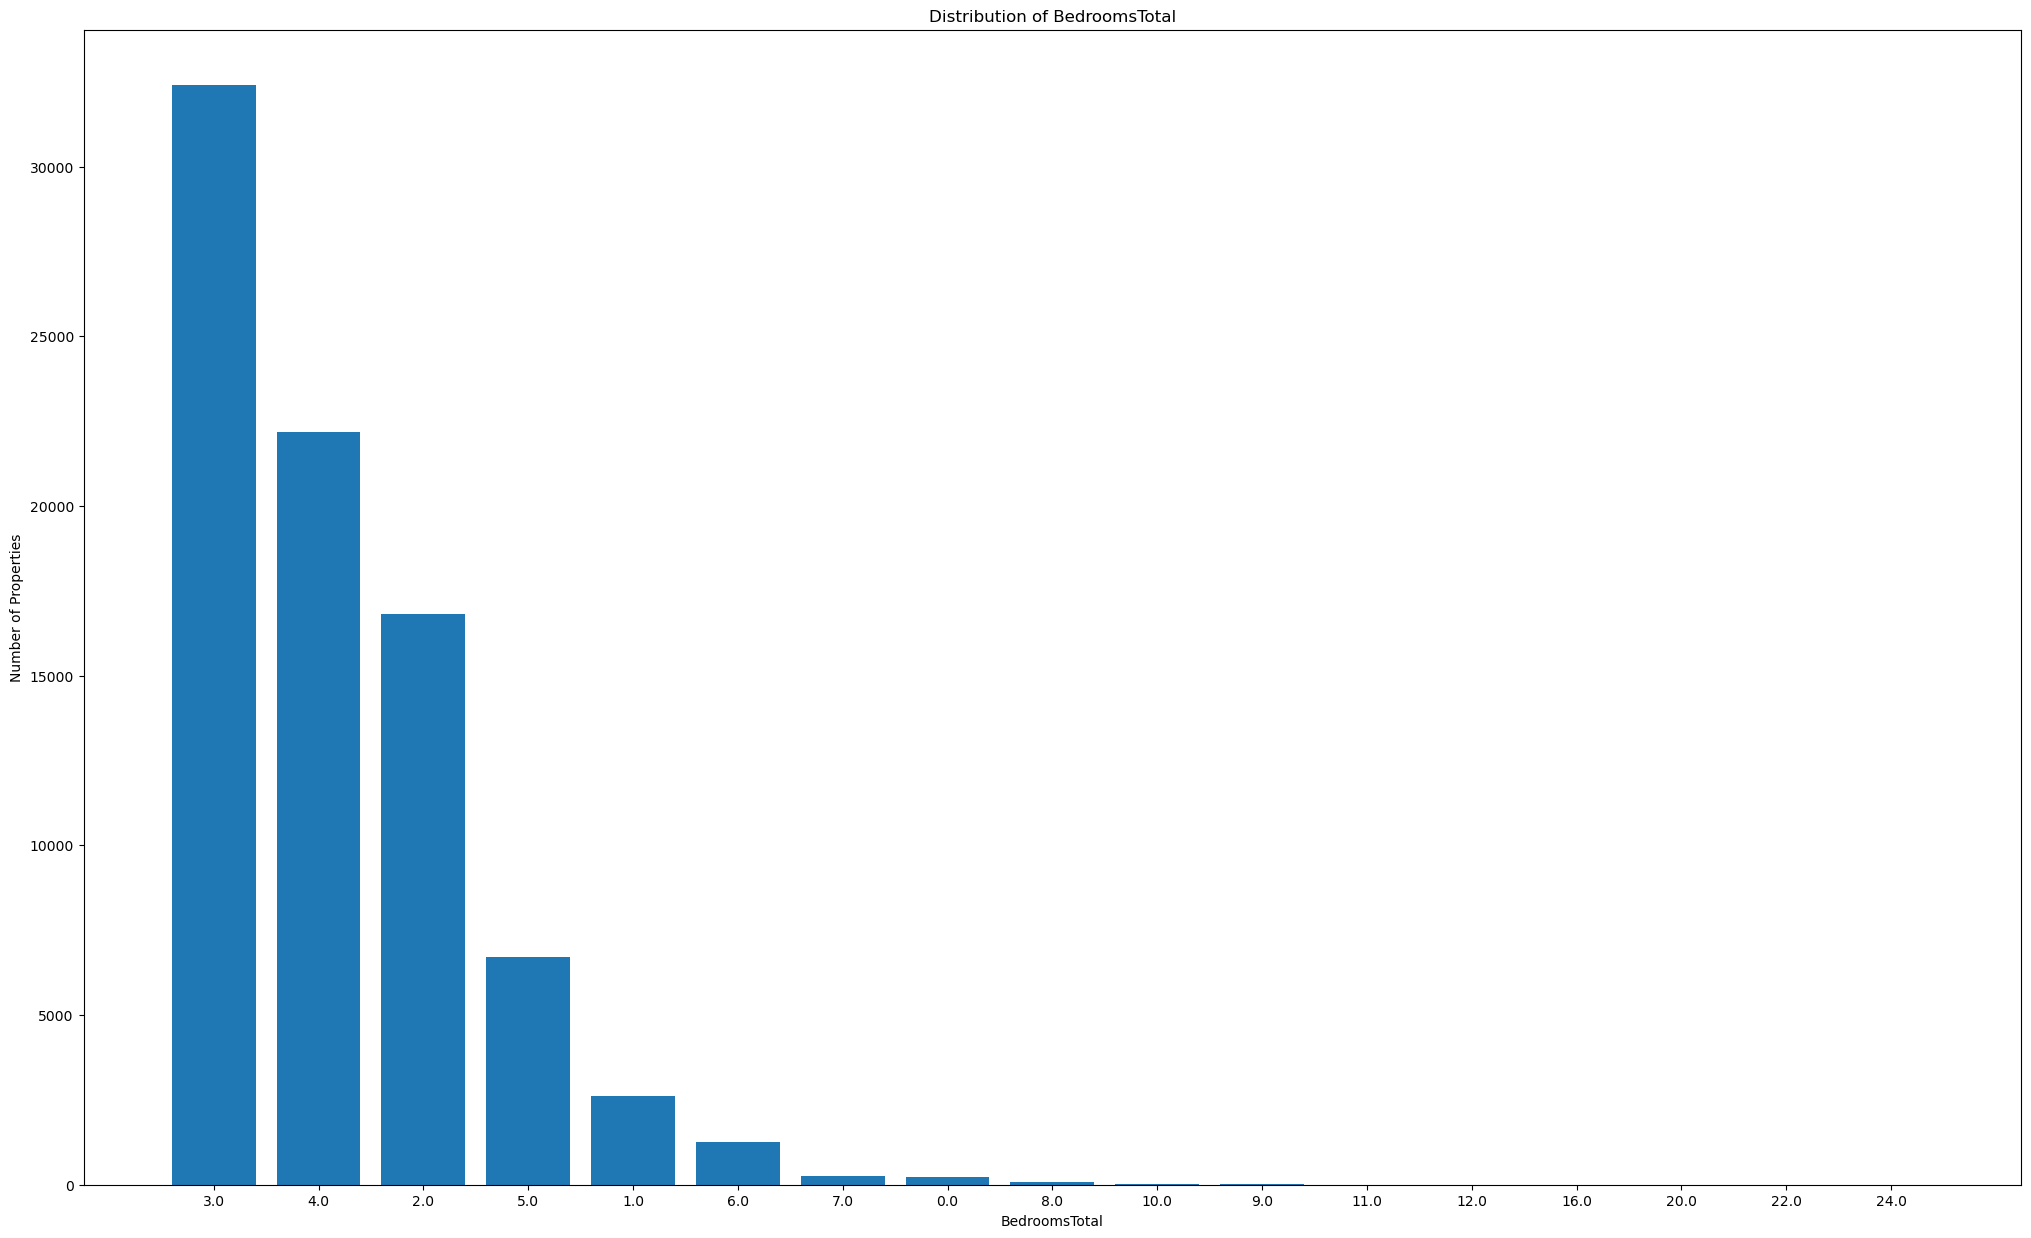

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["BedroomsTotal"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["BedroomsTotal"].value_counts().head(30).values)
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.title("Distribution of BedroomsTotal")
plt.show()

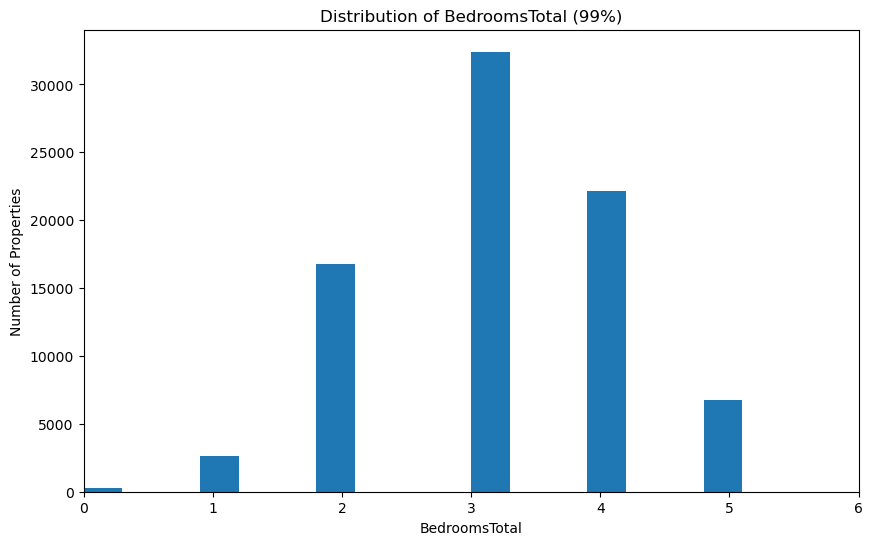

In [100]:
import matplotlib.pyplot as plt
upper = dataset_total_last6_r["BedroomsTotal"].quantile(0.99)
plt.figure(figsize=(10,6))
plt.hist(dataset_total_last6_r["BedroomsTotal"], bins=80)
plt.xlim(0, upper)
plt.xlabel("BedroomsTotal")
plt.ylabel("Number of Properties")
plt.title("Distribution of BedroomsTotal (99%)")
plt.show()

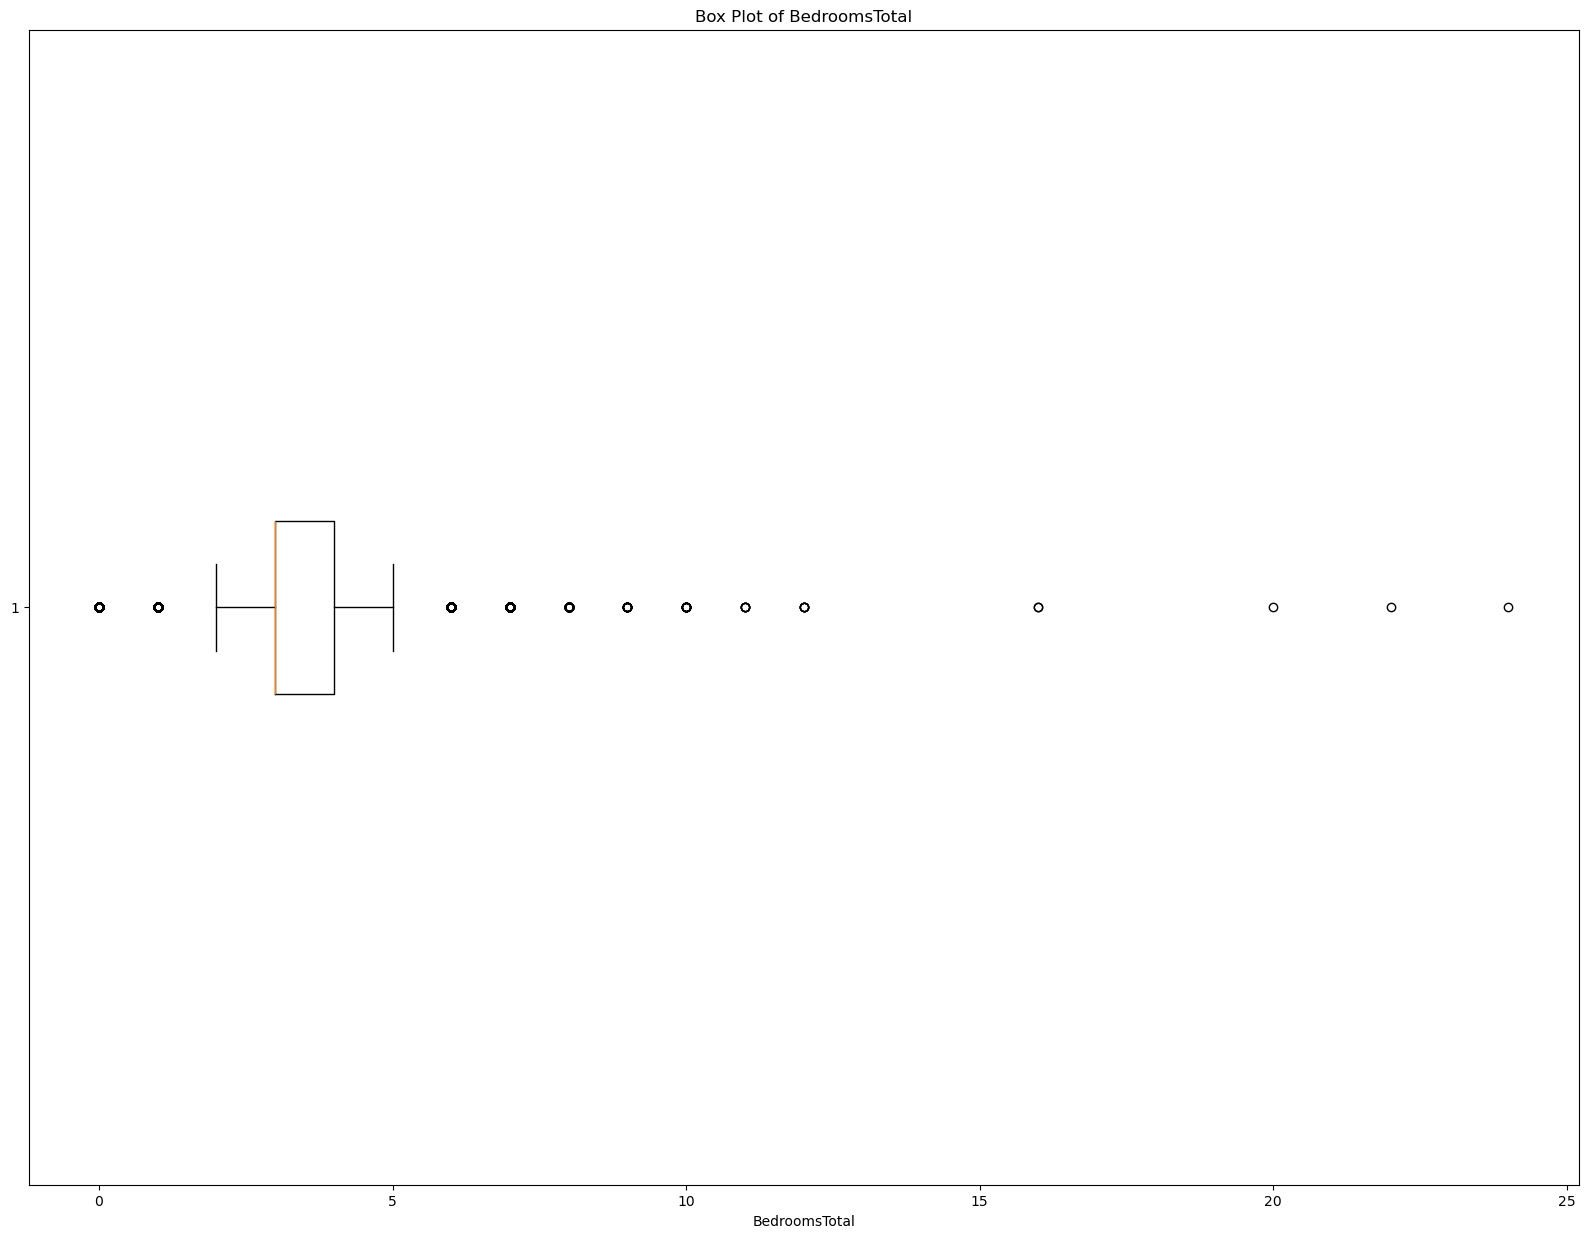

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["BedroomsTotal"].dropna(), vert=False)

plt.title("Box Plot of BedroomsTotal")
plt.xlabel("BedroomsTotal")
plt.show()

## 5. LotSize

**Definition of LotSizeArea**: The total area of the lot. See Lot Size Units for the units of measurement (Square Feet, Square Meters, Acres, etc.).

**Definition of LotSizeDimensions**: The dimensions of the lot minimally represented as length and width (i.e. $250 x 180$) or a measurement of all sides of the polygon representing the property lines of the property. i.e. $30 x 50 x 120 x 60 x 22$.

**Definition of LotSizeSquareFeet**: The total square footage of the lot. This field is related to the Lot Size Area and Lot Size Units and must be in sync with the values represented in those fields. Lot Size Source also applies to this field when used.


<span style="color:red"> **Since the dataset does not provide the feature “Lot Size Units”, the “LotSizeArea” variable cannot be reliably used due to inconsistent unit definitions across records.** </span>

**Distribution Analysis:**

**LotSizeDimensions:**

The LotSizeDimensions feature contains a significant number of missing values ($4,070$ out of $82,643$ records). The most common value is "$50$ x $135$", appearing $67$ times, which represents a typical lot dimension format. However, there are also $9$ records with a value of "$0$", which is not a valid dimension and is treated as a missing or erroneous entry. In addition, several irregular values (e.g., "$7405$") do not follow the expected "length x width" format, indicating inconsistent data formatting. Due to the high proportion of missing and malformed entries, this feature requires careful preprocessing and standardization before it can be used reliably in modeling.


**LotSizeSquareFeet:** 

The LotSizeSquareFeet feature also contains a large number of missing or invalid values, with 76,695 records affected. The distribution is highly concentrated between approximately $3,000$ and $12,000$ square feet. The most frequent valid values include $6,000$ and $7,405$ square feet (corresponding to $877$ and $1,247$ occurrences respectively). However, the presence of zero values is not valid, as lot size cannot be zero, and these are treated as missing entries.

The boxplot further indicates a highly right-skewed distribution with numerous extreme outliers. The large discrepancy between the mean ($405,577$ sq ft) and median ($7,318$ sq ft), together with a maximum value of $1.9$ billion sq ft, suggests severe data quality issues and the presence of extreme outliers that heavily distort the distribution.

In [151]:
dataset_total_last6_r["LotSizeArea"].describe()

count    7.672300e+04
mean     4.276512e+04
std      2.219671e+06
min      0.000000e+00
25%      5.000000e+03
50%      7.002000e+03
75%      1.104000e+04
max      4.187423e+08
Name: LotSizeArea, dtype: float64

In [45]:
dataset_total_last6_r["LotSizeArea"].value_counts()

0.0        1538
7405.0     1247
6000.0      877
6098.0      830
6534.0      783
           ... 
21146.0       1
83258.0       1
24039.0       1
24883.0       1
30457.0       1
Name: LotSizeArea, Length: 20181, dtype: int64

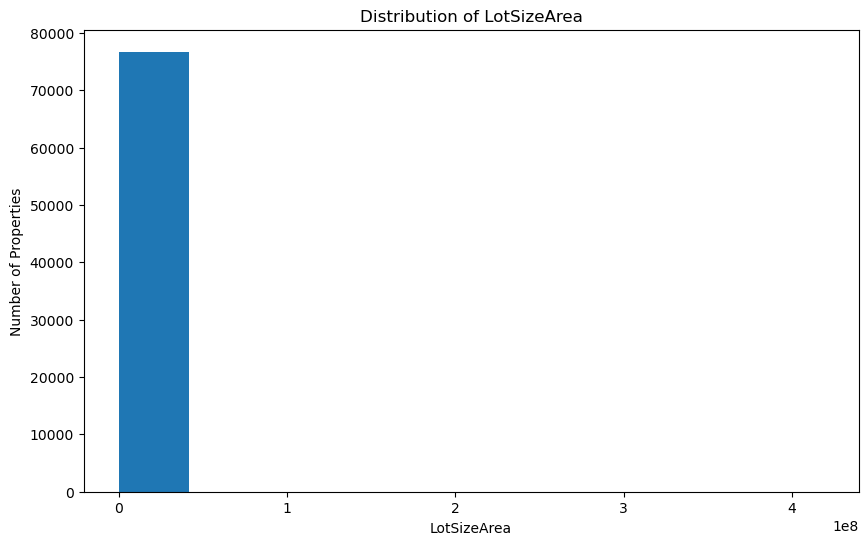

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_total_last6_r["LotSizeArea"])
plt.xlabel("LotSizeArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeArea")
plt.show()

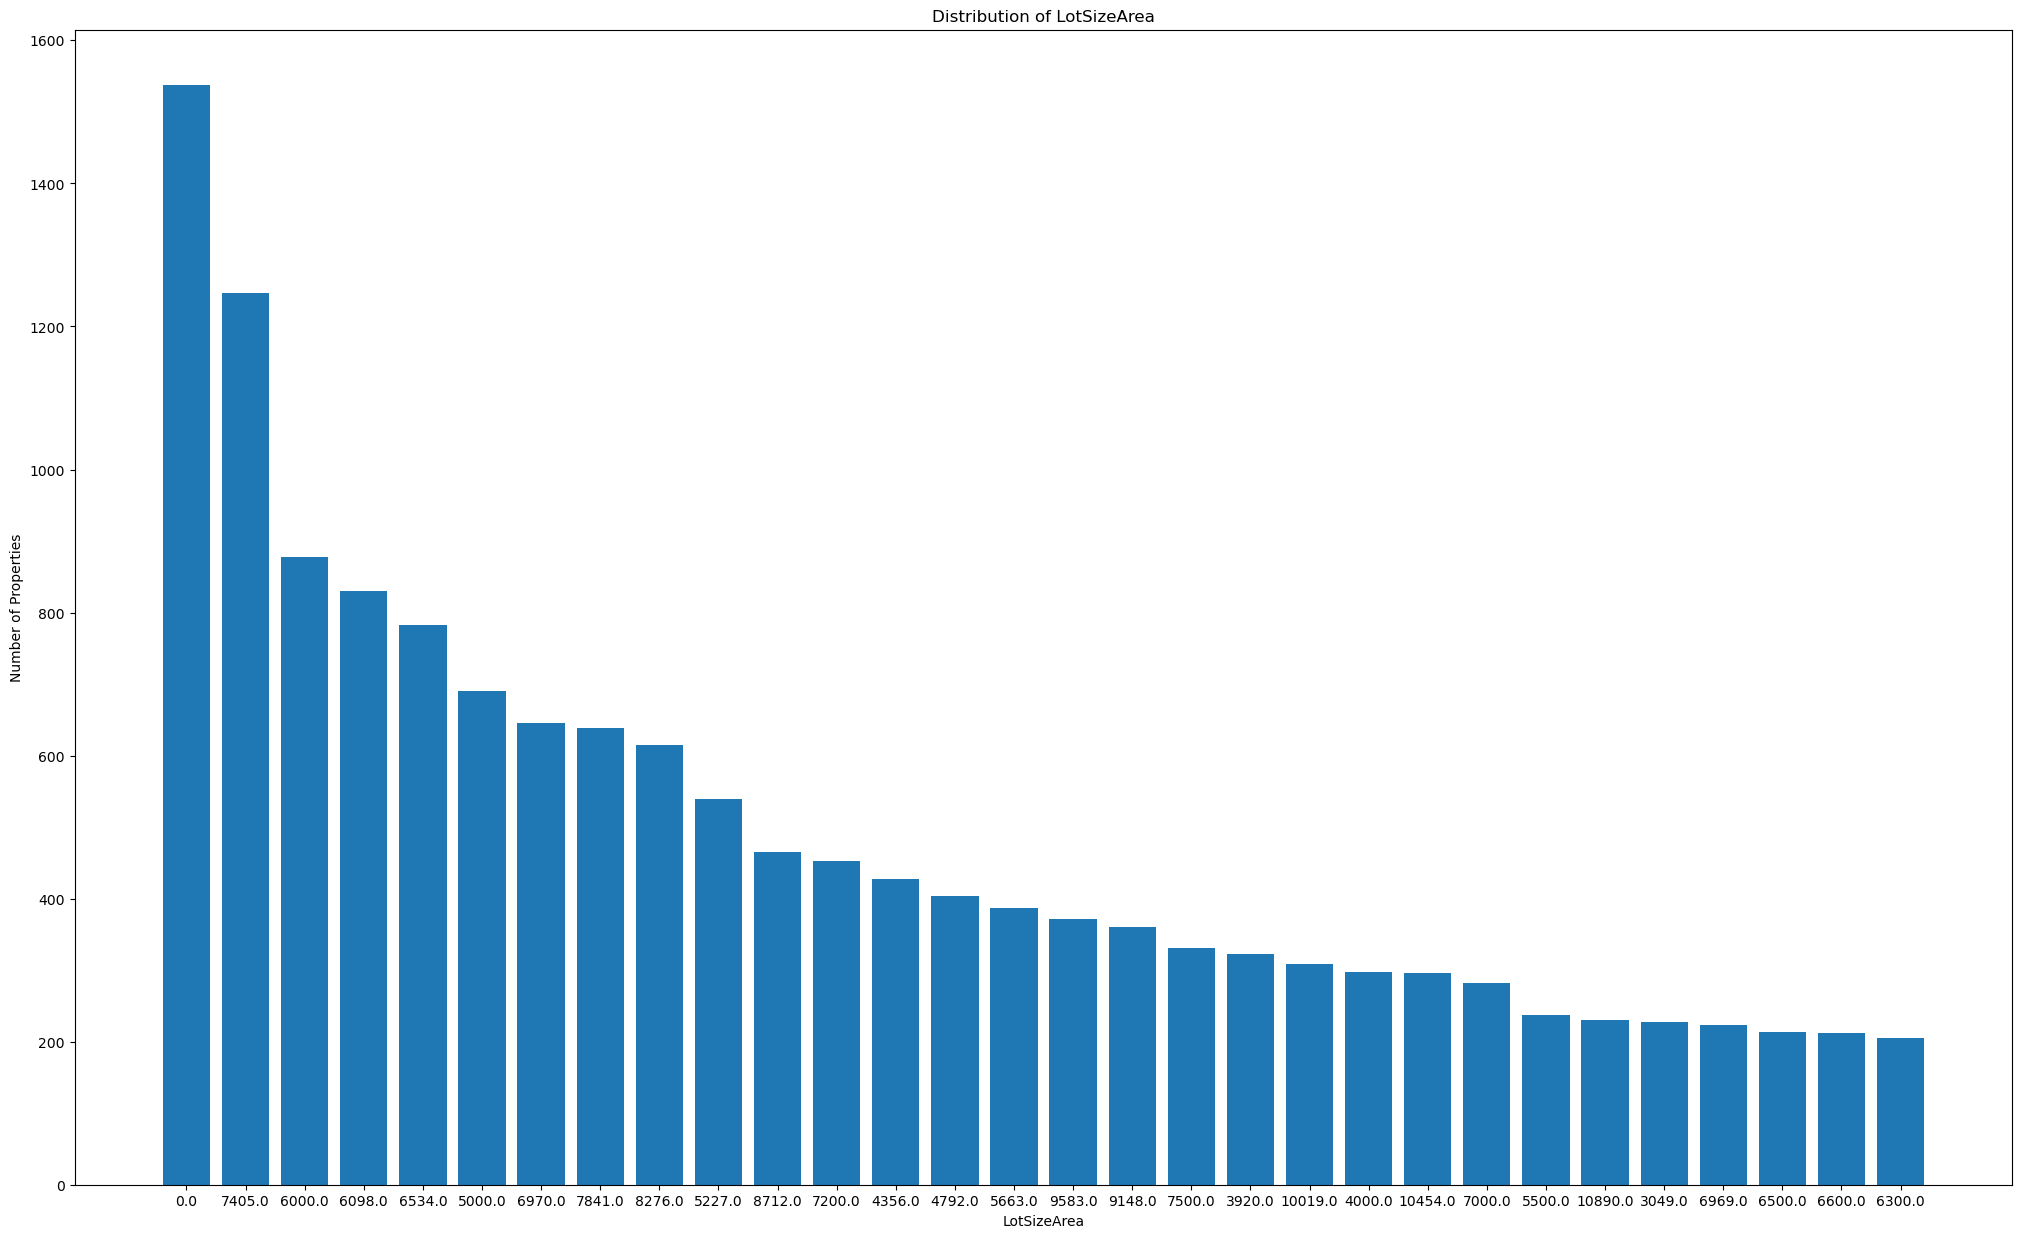

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.bar(dataset_total_last6_r["LotSizeArea"].value_counts().head(30).index.astype('str'),dataset_total_last6_r["LotSizeArea"].value_counts().head(30).values)
plt.xlabel("LotSizeArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeArea")
plt.show()

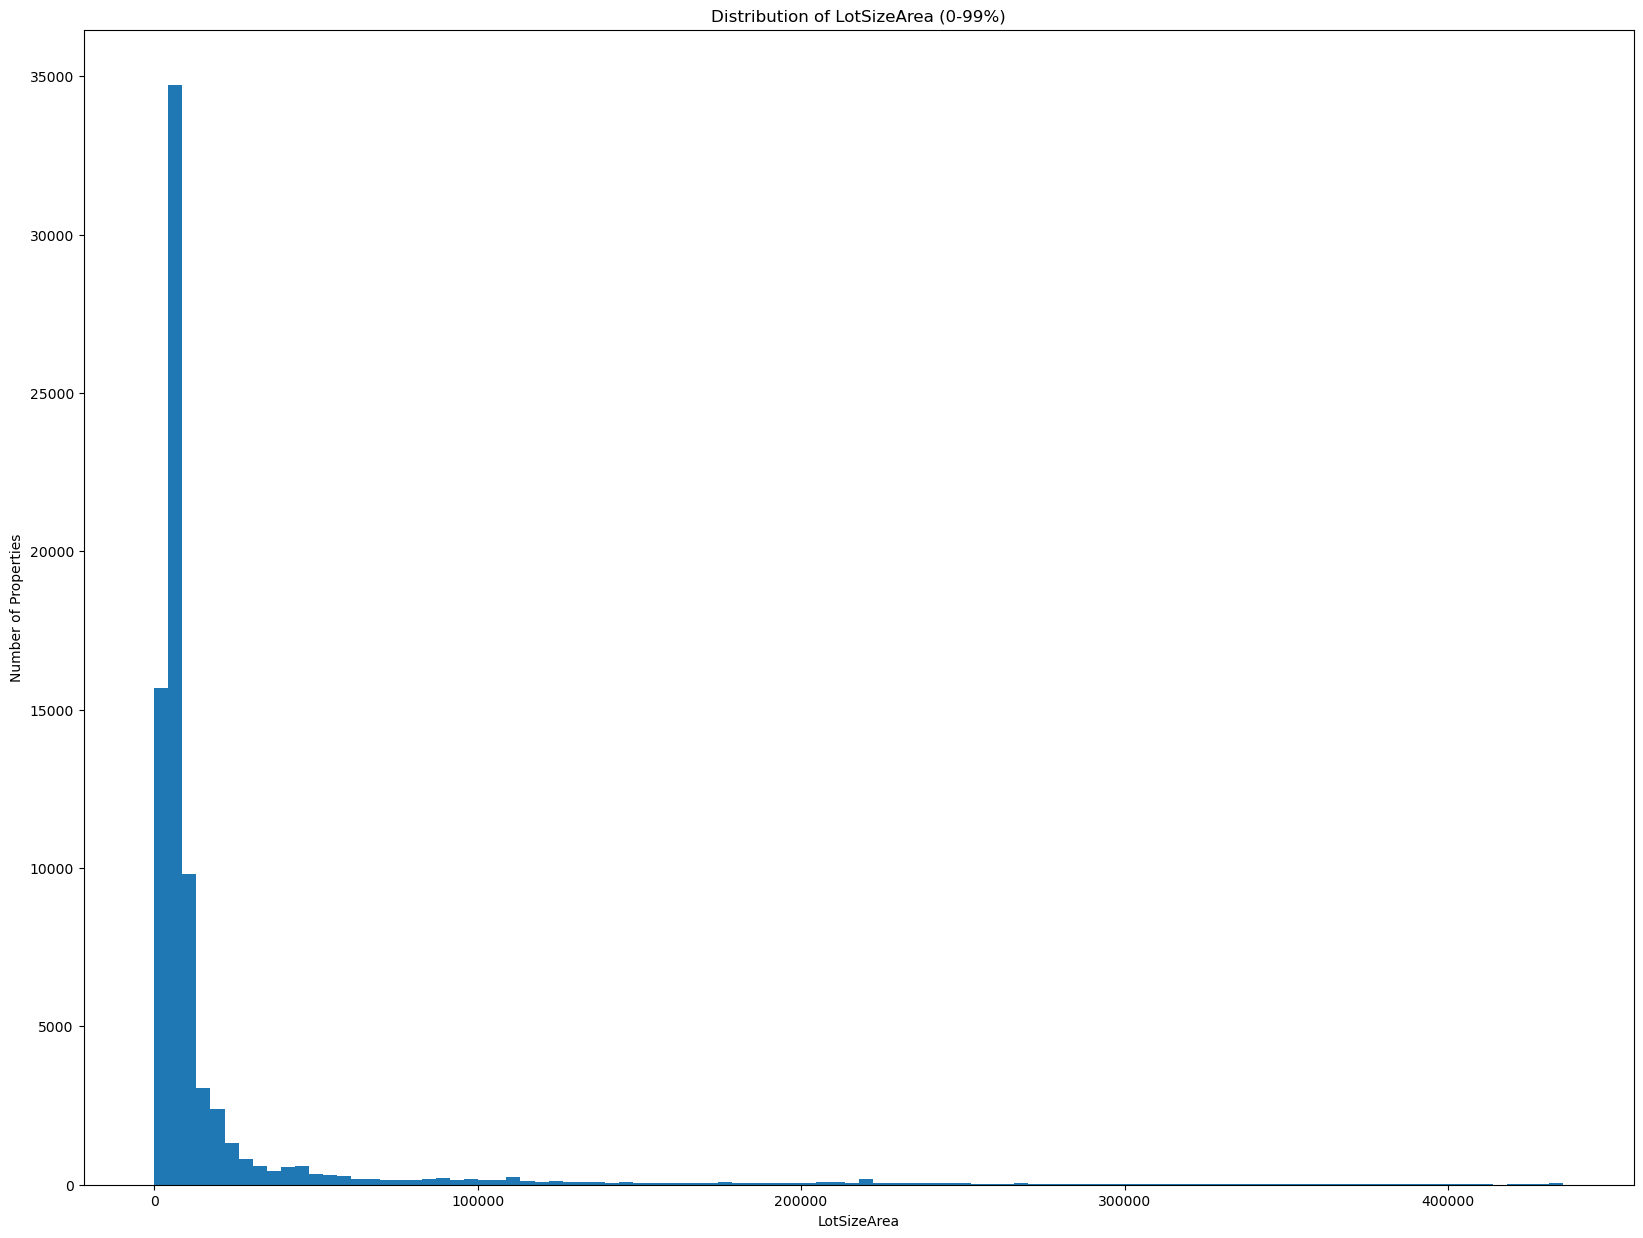

In [109]:
upper = dataset_total_last6_r["LotSizeArea"].quantile(0.99)
data = dataset_total_last6_r[ dataset_total_last6_r["LotSizeArea"] <= upper]["LotSizeArea"]
plt.figure(figsize=(20,15))
plt.hist(data, bins=100)
plt.xlabel("LotSizeArea")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeArea (0-99%)")
plt.show()

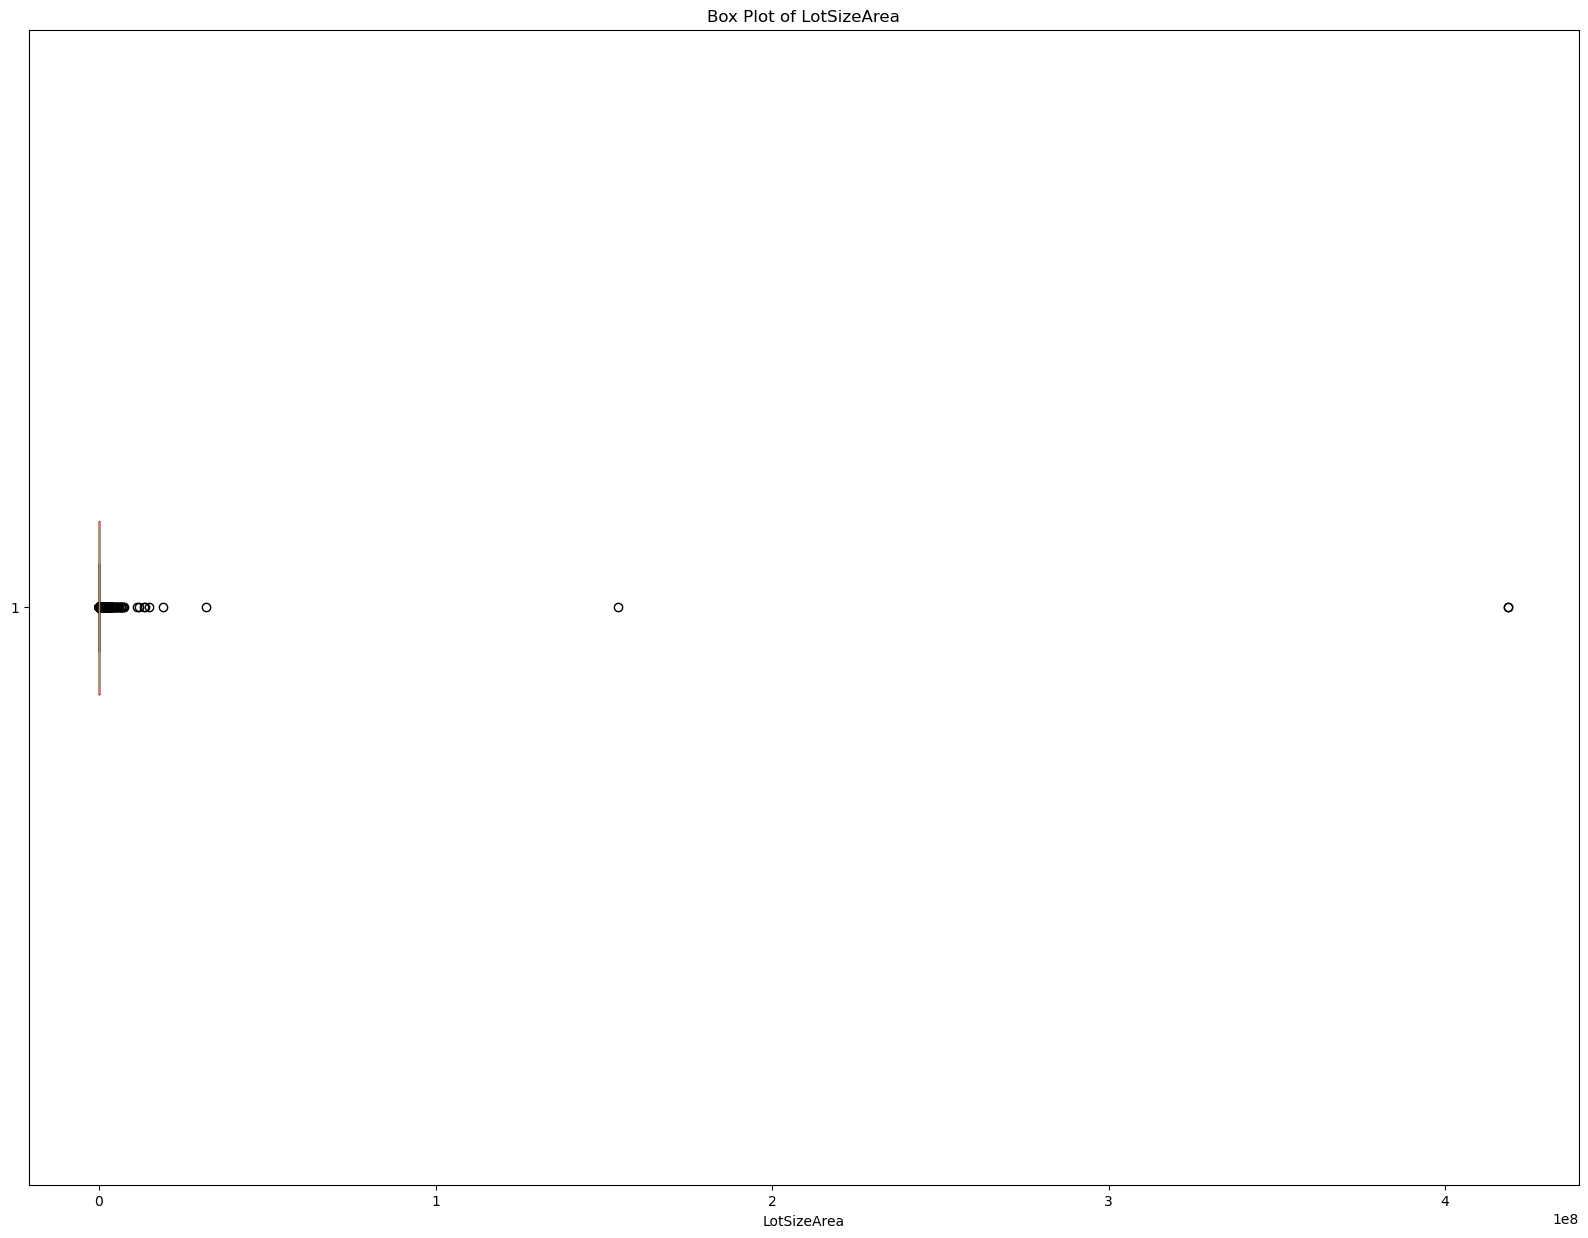

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plt.boxplot(dataset_total_last6_r["LotSizeArea"].dropna(), vert=False)

plt.title("Box Plot of LotSizeArea")
plt.xlabel("LotSizeArea")
plt.show()

LotSizeDimensions:The dimensions of the lot minimally represented as length and width (i.e. 250 x 180) or a measurement of all sides of the polygon representing the property lines of the property. i.e. 30 x 50 x 120 x 60 x 22.

In [46]:
dataset_total_last6_r["LotSizeDimensions"].value_counts()

50x135    67
50x100    48
50x130    46
50x120    42
50x150    41
          ..
2716       1
62x118     1
78x230     1
91x90      1
71.57      1
Name: LotSizeDimensions, Length: 2744, dtype: int64

In [137]:
dataset_total_last6_r["LotSizeDimensions"].describe()

count       4070
unique      2744
top       50x135
freq          67
Name: LotSizeDimensions, dtype: object

In [144]:
sum(dataset_total_last6_r["LotSizeDimensions"]=="0")

9

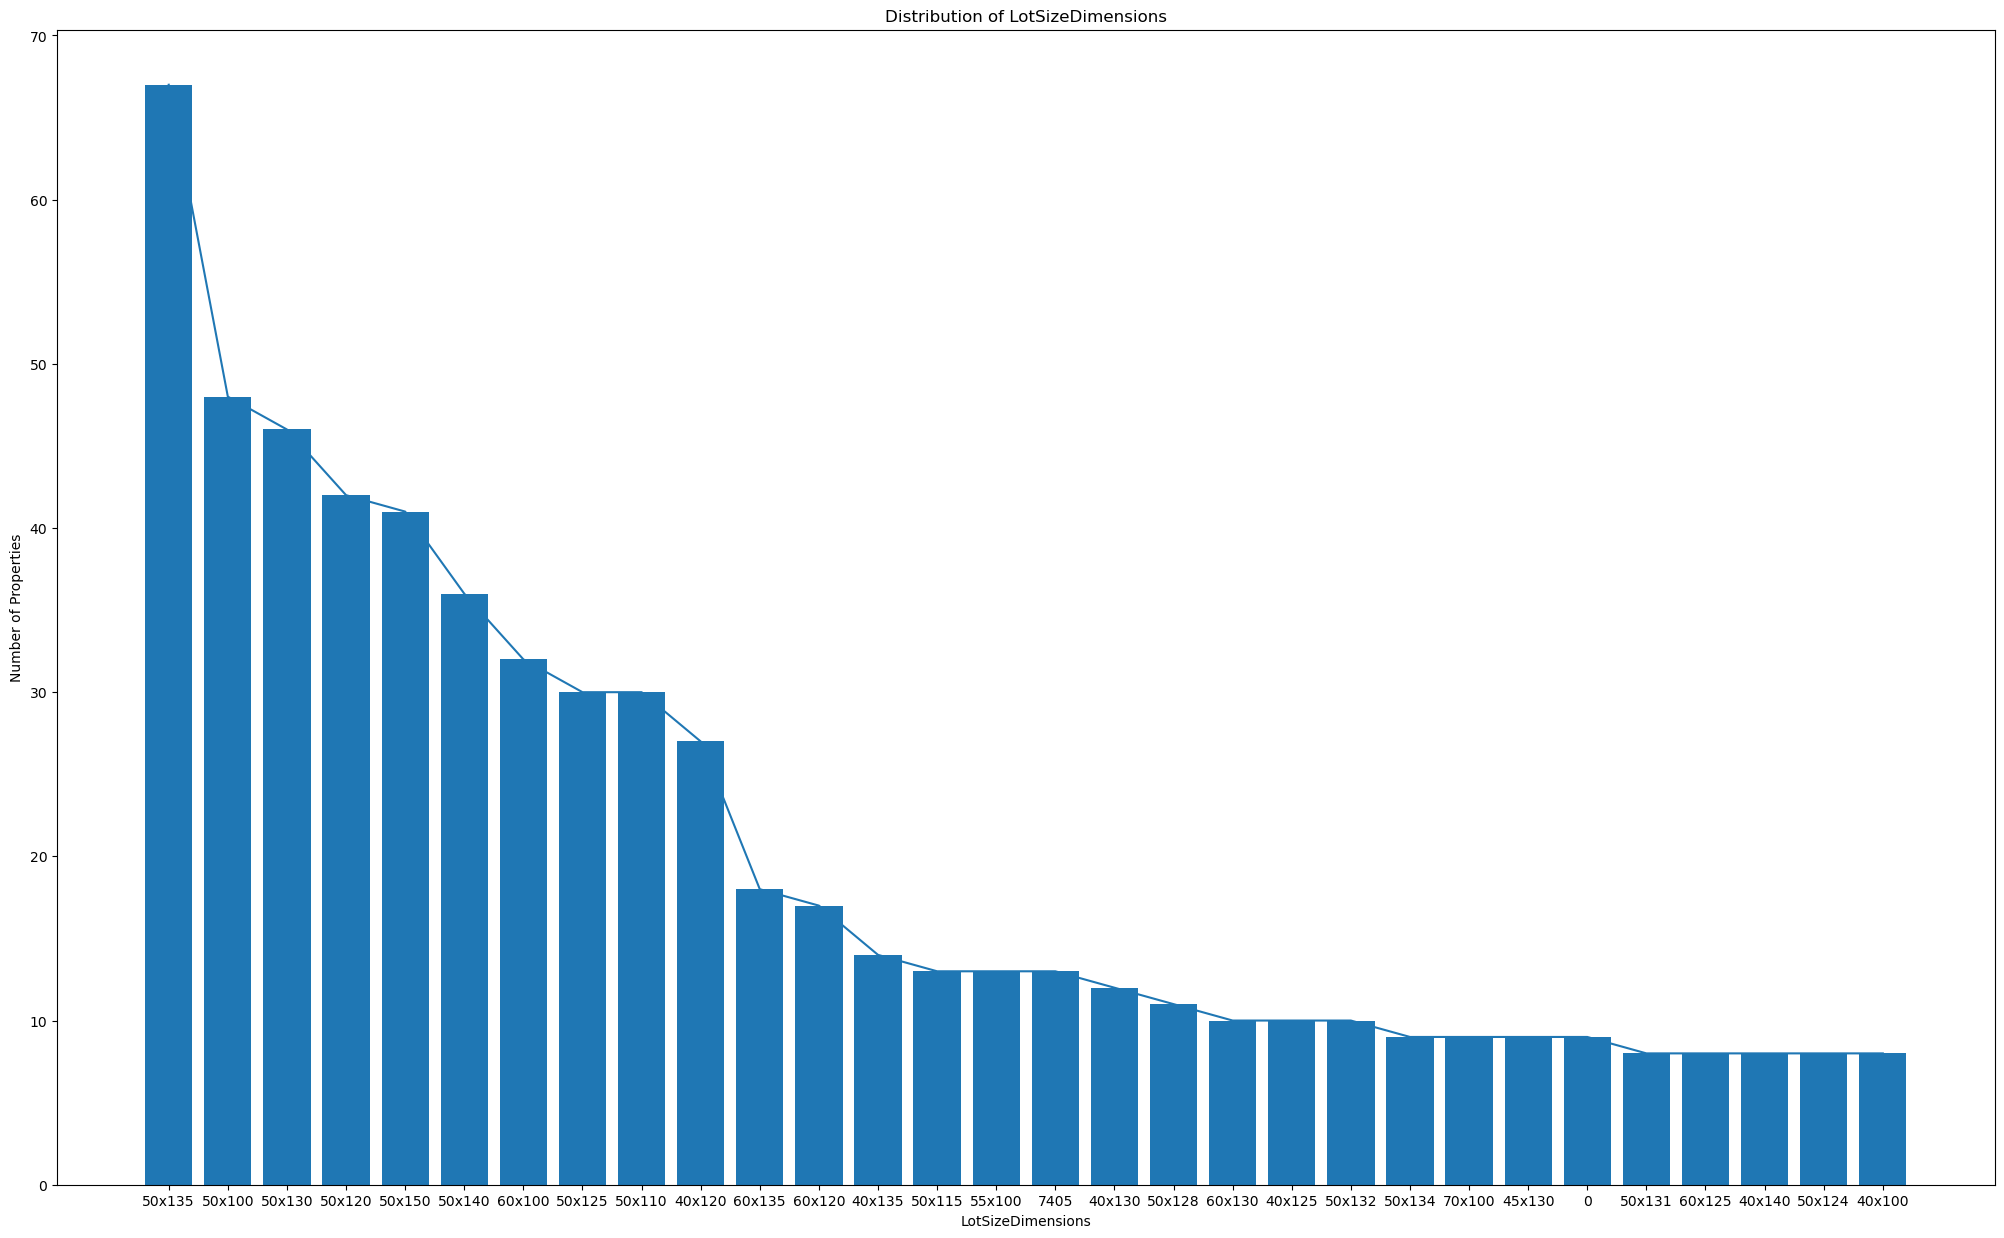

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.plot(dataset_total_last6_r["LotSizeDimensions"].value_counts().head(30))
plt.bar(dataset_total_last6_r["LotSizeDimensions"].value_counts().head(30).index,dataset_total_last6_r["LotSizeDimensions"].value_counts().head(30).values)
plt.xlabel("LotSizeDimensions")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeDimensions")
plt.show()

LotSizeSquareFeet: The total square footage of the lot. This field is related to the Lot Size Area and Lot Size Units and must be in sync with the values represented in those fields. Lot Size Source also applies to this field when used.

In [47]:
dataset_total_last6_r["LotSizeSquareFeet"].value_counts()

0.0          1538
7405.0       1247
6000.0        877
6534.0        852
6098.0        830
             ... 
30962.0         1
1178775.0       1
14178.0         1
730.0           1
30457.0         1
Name: LotSizeSquareFeet, Length: 20176, dtype: int64

In [138]:
dataset_total_last6_r["LotSizeSquareFeet"].describe()

count    7.669500e+04
mean     4.055767e+05
std      1.847170e+07
min      0.000000e+00
25%      5.253000e+03
50%      7.318000e+03
75%      1.245400e+04
max      1.897866e+09
Name: LotSizeSquareFeet, dtype: float64

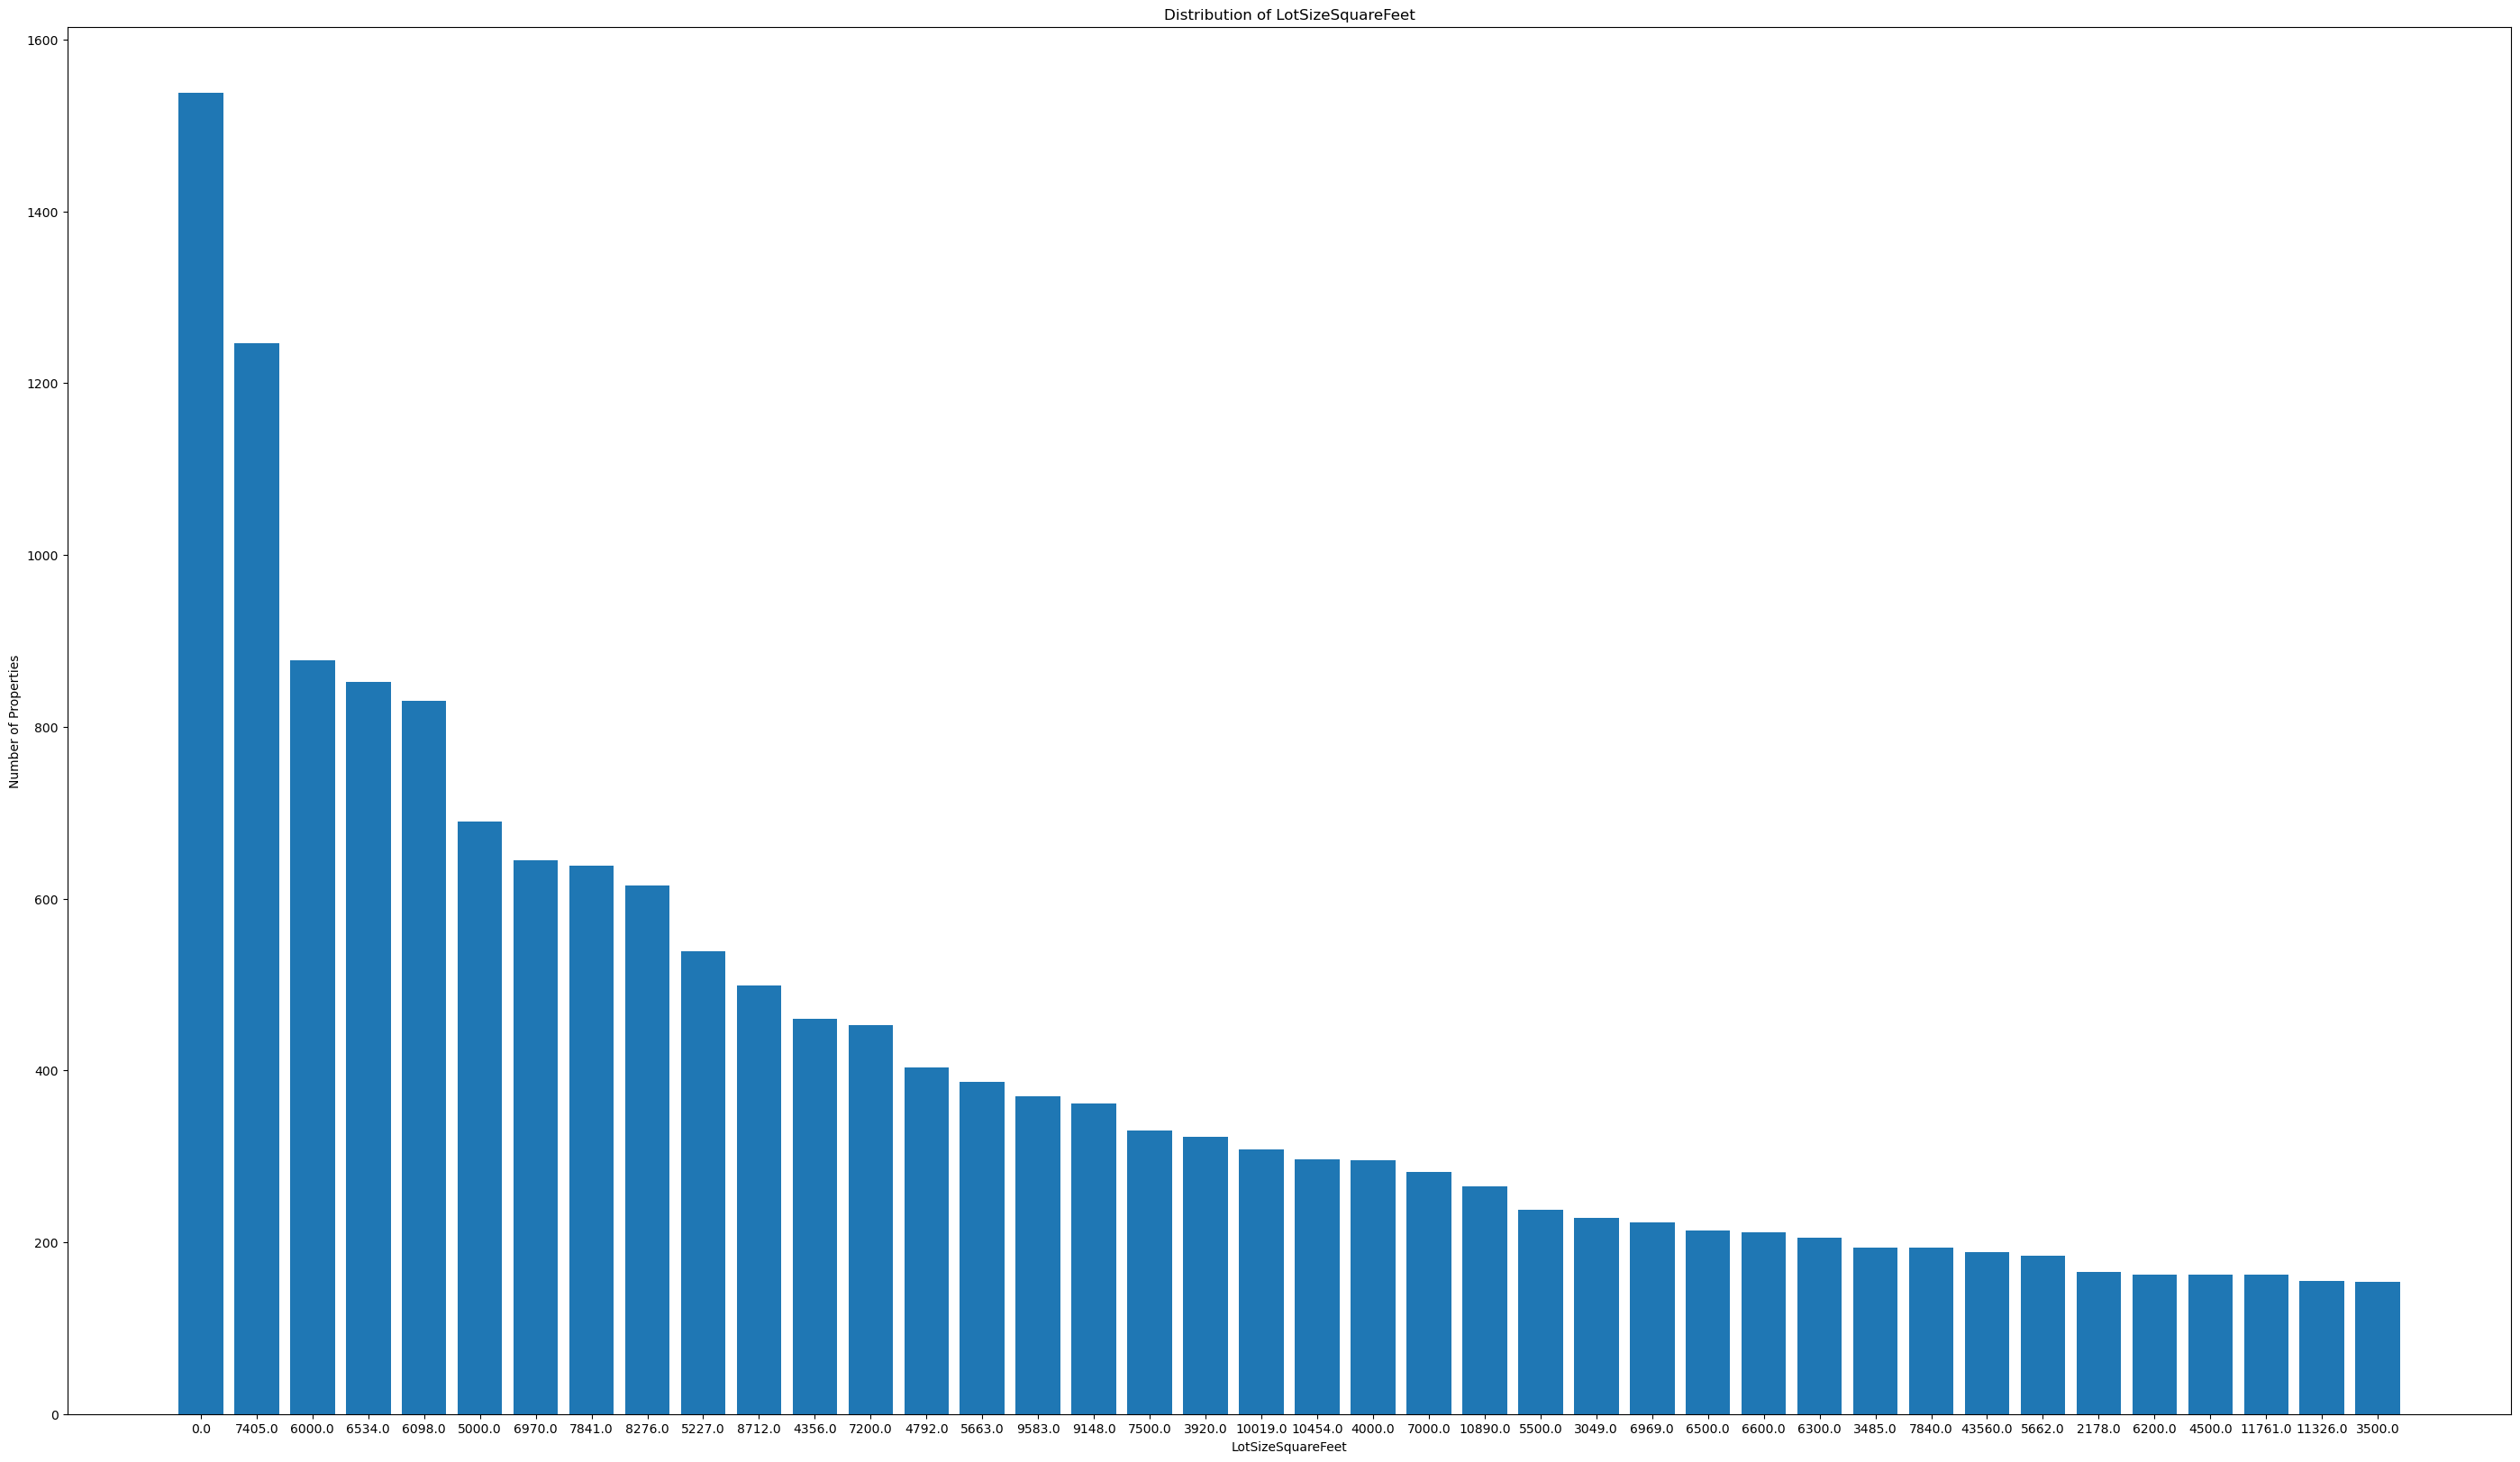

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(35, 20))
plt.bar(dataset_total_last6_r["LotSizeSquareFeet"].value_counts().head(40).index.astype(str),dataset_total_last6_r["LotSizeSquareFeet"].value_counts().head(40).values)
plt.xlabel("LotSizeSquareFeet")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeSquareFeet")
plt.show()

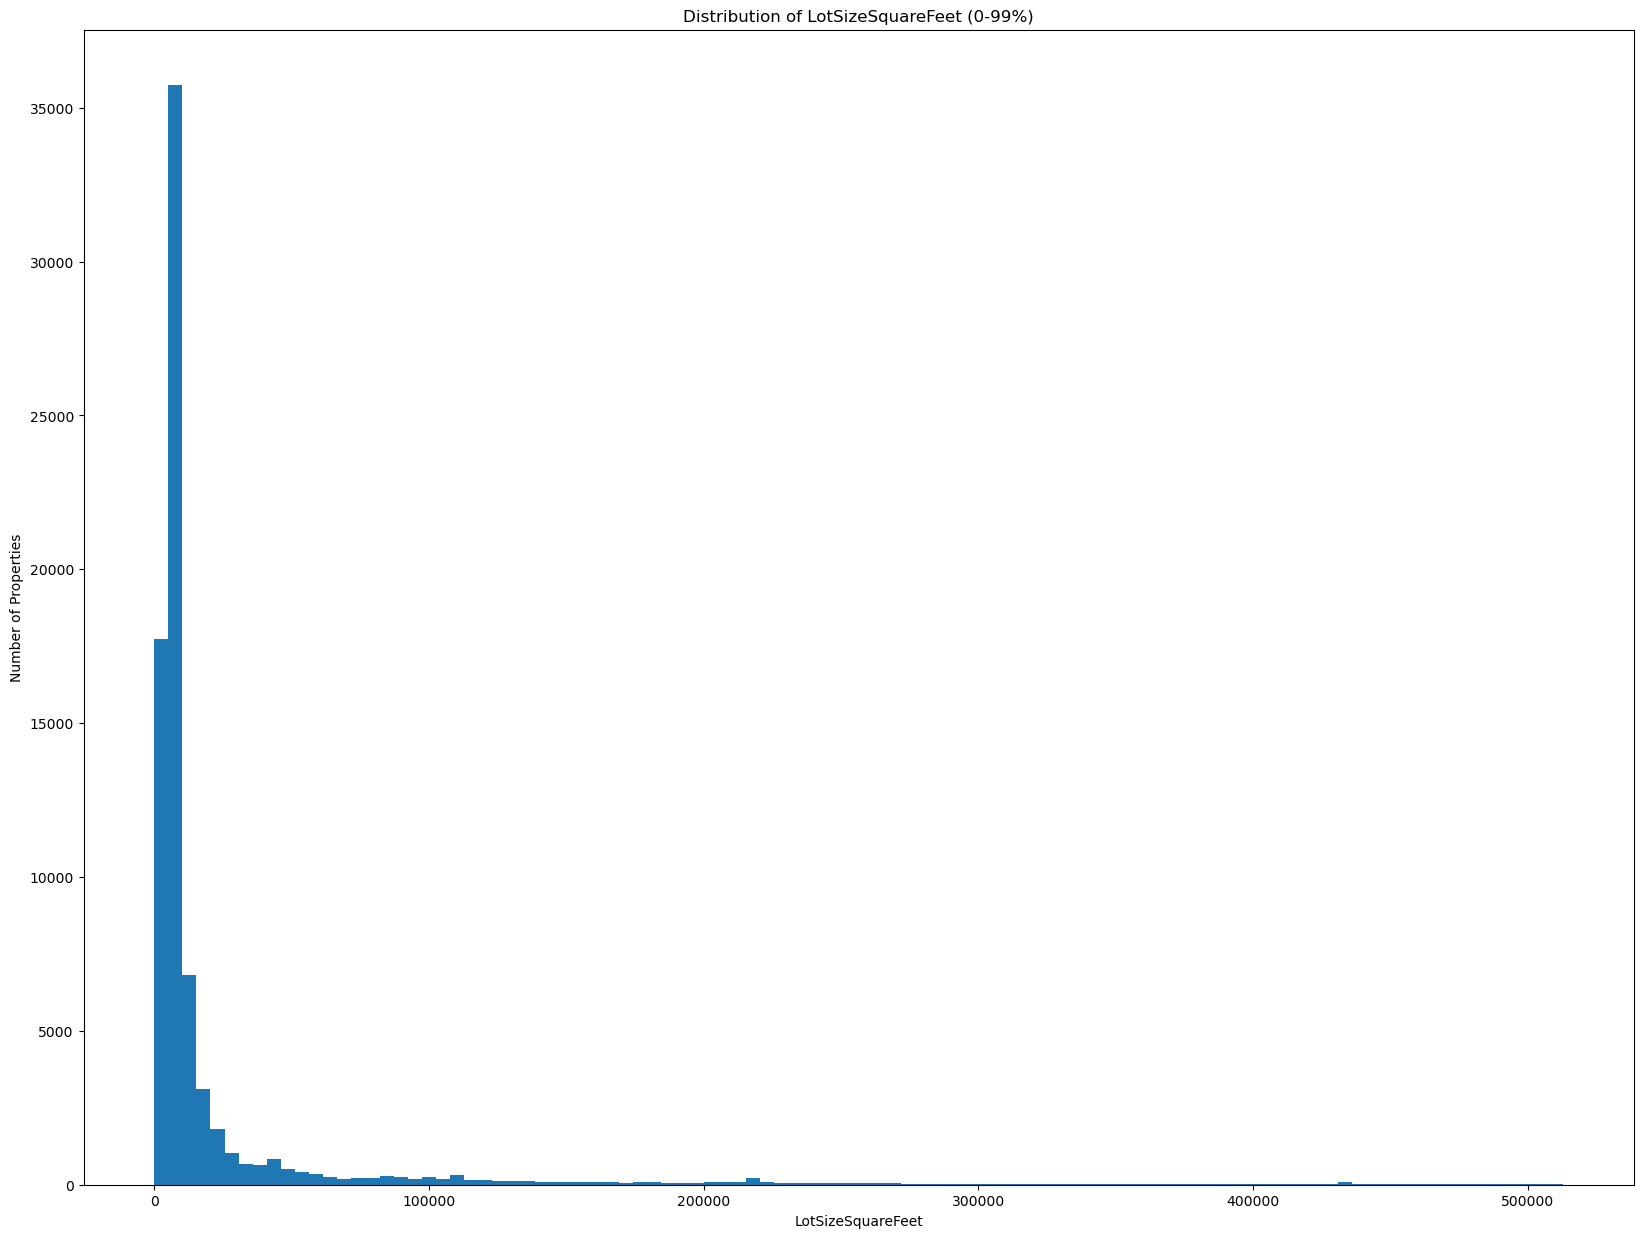

In [110]:
upper = dataset_total_last6_r["LotSizeSquareFeet"].quantile(0.99)
data = dataset_total_last6_r[ dataset_total_last6_r["LotSizeSquareFeet"] <= upper]["LotSizeSquareFeet"]
plt.figure(figsize=(20,15))
plt.hist(data, bins=100)
plt.xlabel("LotSizeSquareFeet")
plt.ylabel("Number of Properties")
plt.title("Distribution of LotSizeSquareFeet (0-99%)")
plt.show()

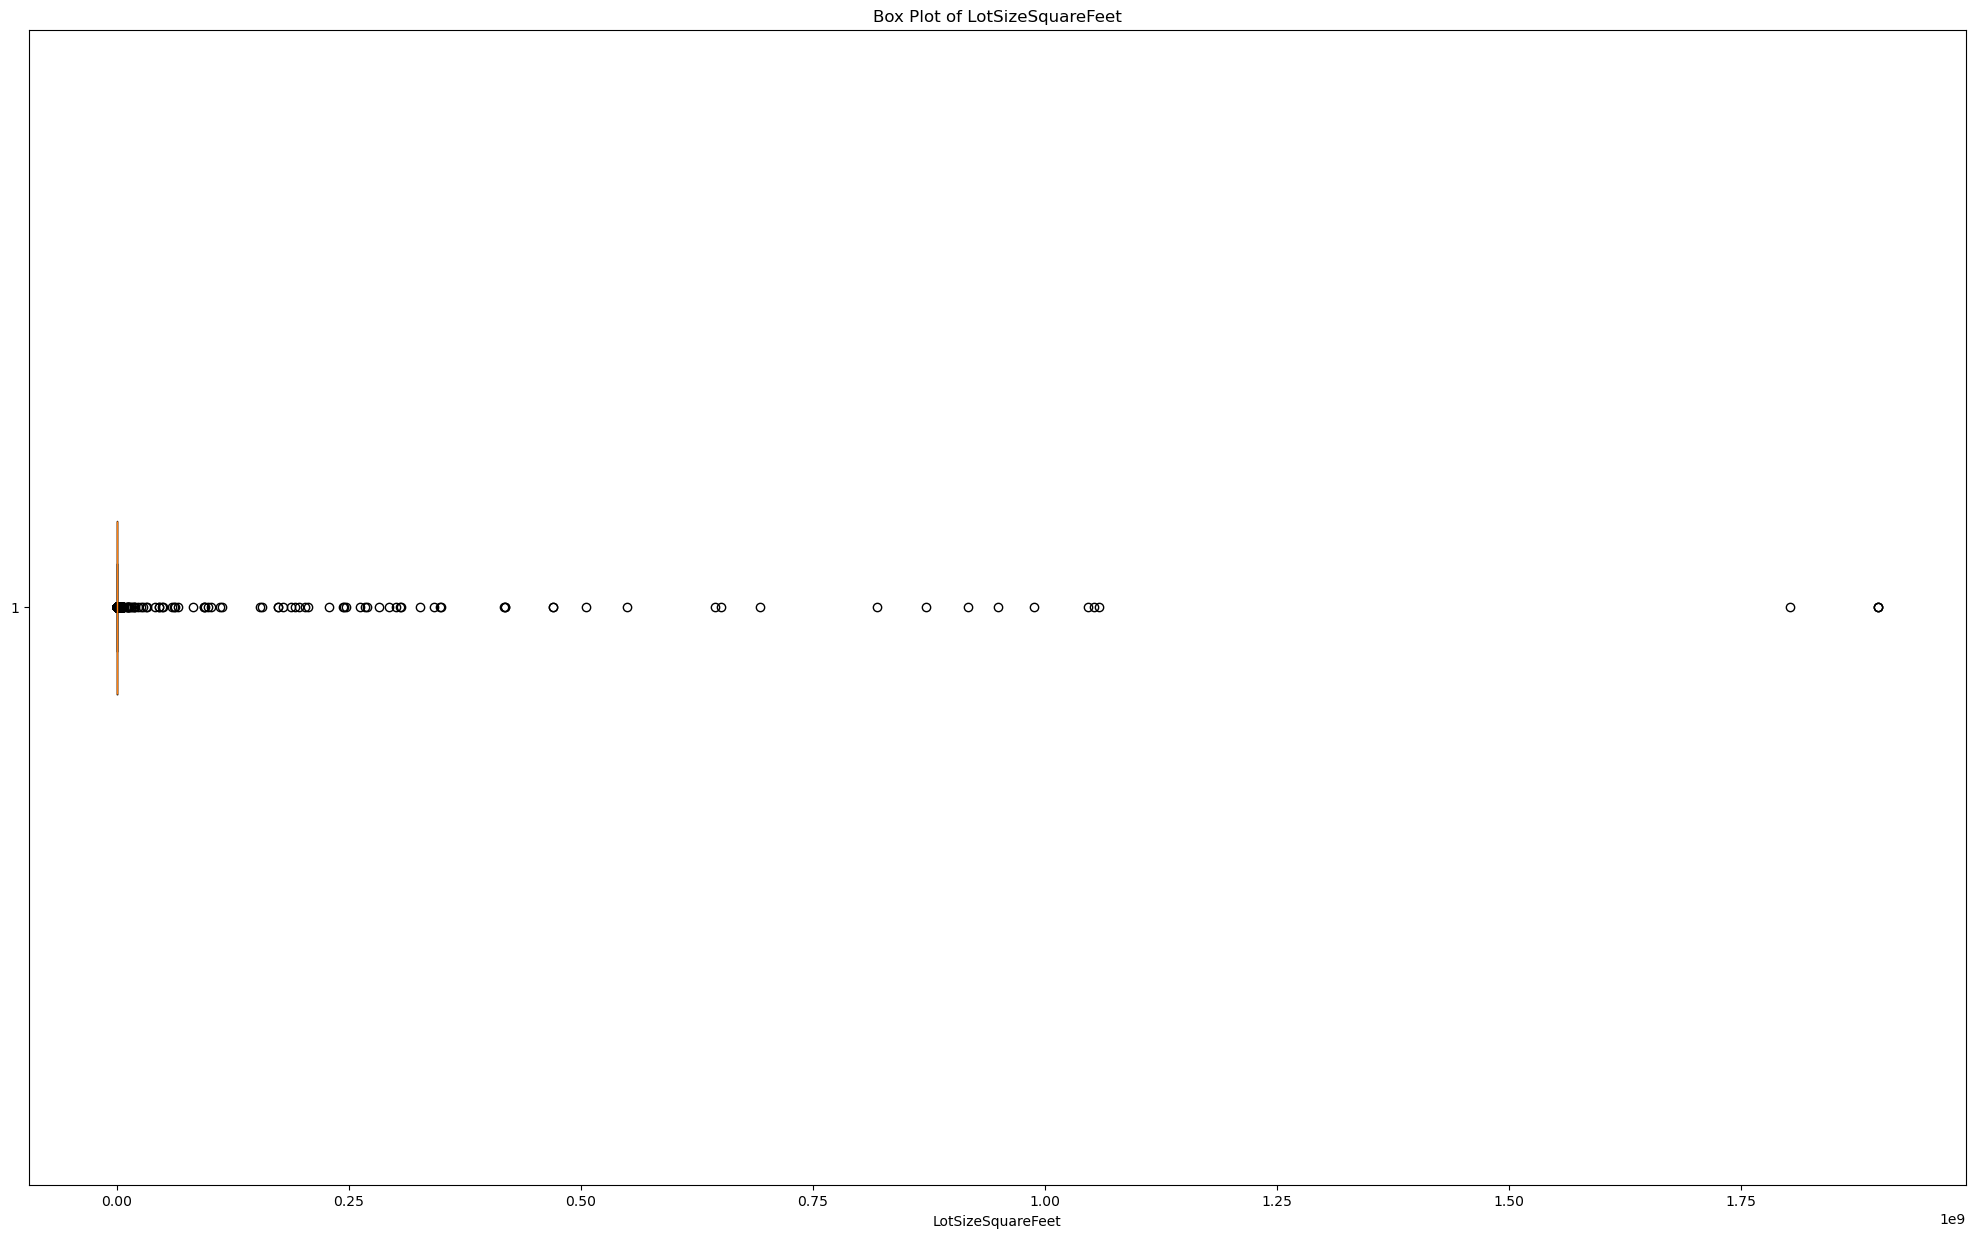

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plt.boxplot(dataset_total_last6_r["LotSizeSquareFeet"].dropna(), vert=False)

plt.title("Box Plot of LotSizeSquareFeet")
plt.xlabel("LotSizeSquareFeet")
plt.show()

## Correlation Analysis

ClosePrice shows weak positive correlations with LivingArea (0.12), BathroomsTotalInteger (0.10), and BedroomsTotal (0.06), while LotSizeSquareFeet has almost no linear correlation with ClosePrice. This suggests that these individual features alone are not strong predictors of house prices, and other factors may also play important roles.

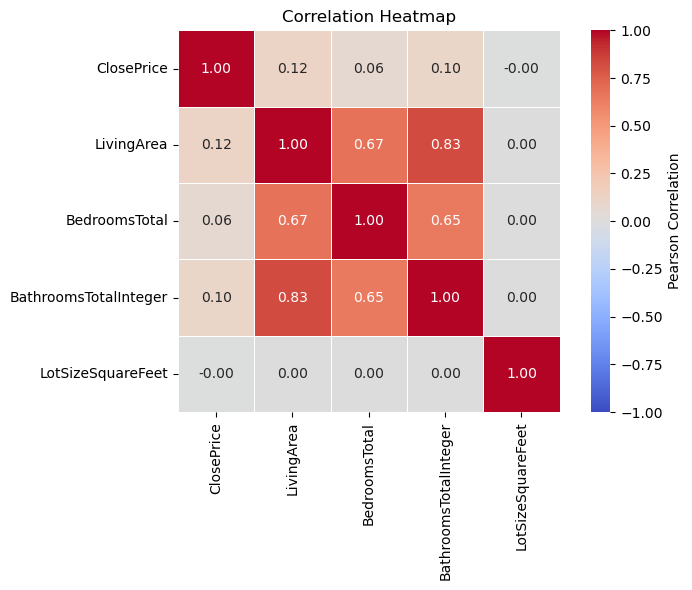

In [157]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = dataset_total_last6_r.copy()

df["LivingArea"] = df["LivingArea"].replace(0, np.nan)
df["LotSizeSquareFeet"] = df["LotSizeSquareFeet"].replace(0, np.nan)

cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

corr = df[cols].dropna().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,          fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1,center=0,square=True,linewidths=0.5,cbar_kws={"label": "Pearson Correlation"})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()